# VXD – Volatilitätsbasierte Frühindikatoren für ein Ampelsystem

### Eine explorative Datenanalyse des VXD (CBOE DJIA Volatility Index)

Diese Analyse überträgt die Methodik des VIX-Notebooks auf den **VXD** und
untersucht neun Hypothesen zur Aussagekraft dieses Volatilitätsindex sowie
verwandter Kennzahlen als Bausteine für ein indikatorbasiertes **Ampelsystem**
(Grün = ruhiges Fahrwasser, Gelb = angespannt, Rot = Ausnahmezustand). Der VXD
bezieht sich dabei auf seinen eigenen zugrunde liegenden Aktienindex, den
**Dow Jones Industrial Average** – nicht auf den S&P 500. Ziel ist die Identifikation robuster
Signale sowie die datenbasierte Herleitung VXD-spezifischer Ampel-Schwellen.

Jede Hypothese wird in einheitlichen Schritten behandelt: Vorstellung und
Motivation, statistische bzw. grafische Auswertung, Interpretation der
Ergebnisse sowie eine Einschätzung der
praktischen Relevanz für das Ampelsystem.

**Aufbau:**

1. Datenbezug und Aufbereitung
2. Datenbereinigung und Plausibilisierung
3. Methodik und Hypothesenübersicht
4. Hypothesenanalyse
5. Einordnung und Handlungsempfehlungen
6. Ampel-Systematik auf Basis des VXD
7. Was-wäre-wenn-Analyse
8. Export der Ergebnisse
9. Zusammenfassung


## 1. Datenbezug und Aufbereitung

Grundlage der Analyse sind historische Tageskursdaten des VXD sowie des
Dow Jones als Vergleichsindex. Dieser Abschnitt beschreibt die verwendeten
Software-Werkzeuge und den Datenbezug.


### 1.1 Verwendete Bibliotheken und Konfiguration

- **pandas** – Datenstrukturen und -verarbeitung (tabellarische Zeitreihen).
- **numpy** – numerische Berechnungen.
- **matplotlib** / **seaborn** – grafische Auswertung.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

import yfinance as yf

# Ampel-Farben für konsistente Plots
COLOR_GREEN = "#2ca02c"
COLOR_YELLOW = "#f2c811"
COLOR_RED = "#d62728"

### 1.2 Datenbezug

Die Rohdaten werden direkt in diesem Notebook über die Programmier-
schnittstelle von Yahoo Finance (`yfinance`) bezogen (Volatilitätsindex
mit Ticker `^VXD`, Aktienindex Dow Jones mit Ticker `^DJI`,
tägliche OHLC-Daten ab dem 01.01.2007). Der Zeitraum ab 2007 schließt die
globale Finanzkrise 2008 als Stresstest mit ein.


In [2]:
def lade_yahoo(ticker: str, start: str) -> pd.DataFrame:
    '''Lädt tägliche OHLC-Daten von Yahoo Finance und reduziert auf eine
    einfache Spaltenebene (yfinance liefert bei Einzeltickern gelegentlich
    einen MultiIndex in den Spalten).'''
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


vxd = lade_yahoo("^VXD", "2007-01-01")
dow = lade_yahoo("^DJI", "2007-01-01")

print("VXD:", vxd.shape, vxd.index.min().date(), "-", vxd.index.max().date())
print("Dow Jones:", dow.shape, dow.index.min().date(), "-", dow.index.max().date())

vxd.head()

VXD: (4912, 6) 2007-01-03 - 2026-08-19
Dow Jones: (4938, 6) 2007-01-03 - 2026-08-19


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2007-01-03,11.67,11.67,12.28,11.01,11.40,0
2007-01-04,11.09,11.09,12.25,11.01,11.81,0
2007-01-05,11.83,11.83,11.98,11.37,11.37,0
2007-01-08,11.66,11.66,12.49,11.56,12.15,0
2007-01-09,11.50,11.50,11.99,11.41,11.50,0


## 2. Datenbereinigung und Plausibilisierung

Vor der eigentlichen Analyse werden die Rohdaten systematisch auf typische
Qualitätsprobleme geprüft und anschließend zu einem gemeinsamen Analyse-
Datensatz zusammengeführt.


### 2.1 Datenqualitätsprüfung

Geprüft werden fehlende Werte, doppelte Datumseinträge sowie abweichende
Handelstage zwischen den beiden Zeitreihen (z. B. durch unterschiedliche
Feiertagskalender bei Yahoo Finance).


In [3]:
print("Fehlende Werte VXD:\
", vxd.isna().sum())
print("\
Fehlende Werte Dow Jones:\
", dow.isna().sum())
print("\
Duplizierte Indexwerte VXD:", vxd.index.duplicated().sum())
print("Duplizierte Indexwerte Dow Jones:", dow.index.duplicated().sum())

only_in_vxd = vxd.index.difference(dow.index)
only_in_dow = dow.index.difference(vxd.index)
print(f"\
Handelstage nur im VXD: {len(only_in_vxd)}")
print(f"Handelstage nur im Dow Jones: {len(only_in_dow)}")

Fehlende Werte VXD: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Fehlende Werte Dow Jones: Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
Duplizierte Indexwerte VXD: 0
Duplizierte Indexwerte Dow Jones: 0
Handelstage nur im VXD: 0
Handelstage nur im Dow Jones: 26


### 2.2 Kombinierter Analyse-Datensatz und Zielgrößen

Beide Zeitreihen werden über die gemeinsamen Handelstage verknüpft (inner
join). Zusätzlich werden die tägliche Dow Jones-Rendite (`dow_return`, in %)
sowie die tägliche VXD-Veränderung (`vxd_change`, in Punkten) als abgeleitete
Größen berechnet.


In [4]:
df = pd.DataFrame({
    "vxd_close": vxd["Close"],
    "dow_close": dow["Close"],
}).dropna()

df["dow_return"] = df["dow_close"].pct_change() * 100  # in %
df["vxd_change"] = df["vxd_close"].diff()

print(f"Gemeinsame Handelstage: {len(df)}")
df.describe()

Gemeinsame Handelstage: 4912


,vxd_close,dow_close,dow_return,vxd_change
count,4912.000000,4912.000000,4911.000000,4911.000000
mean,18.435835,22961.481123,0.036513,0.000344
std,7.809084,11332.594463,1.167253,1.820306
min,2.710000,6547.049805,-12.926546,-18.629999
25%,13.590000,13029.174805,-0.417441,-0.700000
50%,16.209999,18499.325195,0.062802,-0.080000
75%,20.972499,32641.191895,0.556037,0.550000
max,74.599998,53585.761719,11.365041,17.999998


## 3. Methodik und Hypothesenübersicht


### 3.1 Ampel-Logik und statistische Referenzgrößen

Als gemeinsame Referenzgröße für die vertiefenden Hypothesen dient der
VXD-Schwellenwert **27** – die datenbasiert (Abschnitt 4.4) hergeleitete
Grenze für den „Ausnahmezustand" (Rot). Anders als beim VIX (Faustregel 20/30)
werden die Schwellen 18/27 aus der VXD-eigenen Verteilung abgeleitet,
sodass sich vergleichbare Ampel-Anteile ergeben.

Zur Bewertung eines Signals wird durchgängig die **Trefferquote** verwendet:
der Anteil der Signaltage, an denen der VXD innerhalb der nächsten `horizon`
Handelstage mindestens einmal über die Schwelle steigt. Sie wird stets mit der
**Baseline** (unbedingte Wahrscheinlichkeit über alle Handelstage) verglichen.

**Einschränkung:** Handelstage sind zeitlich nicht unabhängig voneinander
(hohe Autokorrelation, siehe Abschnitt 4.3). Die berichteten Trefferquoten sind
daher als Anhaltspunkt und nicht als exakte Wahrscheinlichkeitsaussage zu lesen.


In [5]:
# Gemeinsame Konfiguration für die folgenden Abschnitte.
# Die Ampel-Schwellen sind NICHT die VIX-Faustregeln 20/30, sondern datenbasiert
# aus der VXD-eigenen Verteilung abgeleitet (siehe Abschnitt 4.4), sodass sich
# vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb / 9 % Rot)
# ergeben.
VXD_THRESHOLD_GELB = 18  # Grenze Grün/Gelb (datenbasiert, Abschnitt 4.4)
VXD_THRESHOLD_ROT = 27   # Grenze Gelb/Rot, "Ausnahmezustand" (datenbasiert, Abschnitt 4.4)


def forward_hit_rate(signal_mask, horizon, threshold=VXD_THRESHOLD_ROT):
    """Anteil der Tage mit signal_mask == True, an denen der VXD-Schlusskurs
    innerhalb der nächsten `horizon` Handelstage mindestens einmal über
    `threshold` steigt. Tage ohne vollständiges Folgefenster werden ausgeschlossen."""
    vxd_values = df["vxd_close"].values
    mask_values = signal_mask.values if hasattr(signal_mask, "values") else signal_mask
    idx = np.where(mask_values)[0]
    hits, valid = 0, 0
    for i in idx:
        window = vxd_values[i + 1 : i + 1 + horizon]
        if len(window) == 0:
            continue
        valid += 1
        if window.max() > threshold:
            hits += 1
    return hits / valid if valid else np.nan


ALL_DAYS = pd.Series(True, index=df.index)


# --- Prognosehorizonte und Vorwärts-Kennzahlen des Dow Jones --------------------
# Ergänzend zur Trefferquote: Forward-Rendite (Kursveränderung bis horizon Tage
# später) und Forward-Max-Drawdown (größter zwischenzeitlicher Rückgang im
# Fenster [i, i+horizon]) des Dow Jones.
HORIZONS = [5, 10, 15, 30]


def forward_return(close, horizon):
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close, horizon):
    werte = close.values
    n = len(werte)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = werte[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


for _h in HORIZONS:
    df[f"fwd_return_{_h}d"] = forward_return(df["dow_close"], _h)
    df[f"fwd_mdd_{_h}d"] = forward_max_drawdown(df["dow_close"], _h)


def forward_kennzahlen(signal_mask, horizon):
    """Mittlere Forward-Rendite und mittlerer Forward-Max-Drawdown des Dow Jones
    über `horizon` Handelstage für die markierten Tage."""
    maske = signal_mask.reindex(df.index).fillna(False)
    fr = df.loc[maske, f"fwd_return_{horizon}d"]
    mdd = df.loc[maske, f"fwd_mdd_{horizon}d"]
    return fr.mean(), mdd.mean(), int(fr.notna().sum())


print("Vorwärts-Kennzahlen berechnet für Horizonte:", HORIZONS)


Vorwärts-Kennzahlen berechnet für Horizonte: [5, 10, 15, 30]


### 3.2 Untersuchte Hypothesen

| # | Hypothese | Kriterium |
|---|---|---|
| H1 | Ruhiges Fahrwasser vs. Stressphasen | Bewegt sich der VXD im ruhigen Band oder in einer Stressphase? |
| H2 | VXD vs. Dow Jones-Renditen | Wie hängt die VXD-Bewegung mit der Tagesrendite des Index zusammen? |
| H3 | Volatility Clustering | Treten hohe/niedrige VXD-Werte in Clustern auf (Autokorrelation)? |
| H4 | Verteilung & Schwellenwerte | Welche Ampel-Schwellen legt die historische Verteilung nahe? |
| H5 | Dauer der Ampelphasen | Wie lange dauern zusammenhängende Grün-/Gelb-/Rot-Phasen? |
| H6 | Neues 3-Monats-Hoch | Kündigt ein neues 3-Monats-Hoch eine nachfolgende Rot-Phase an? |
| H7 | 3-Punkte-Umkehr | Signalisiert eine ausgeprägte Intraday-Umkehr eine Beruhigung? |
| H8 | VXD-Schwellenwerte | Ab welchem Niveau heben sich reale Stressphasen ab? |
| H9 | Divergenz zum Index | Kündigt untypischer Gleichlauf von VXD und Index Turbulenzen an? |

H1–H5 bilden die Basis-Exploration des VXD, H6–H9 vertiefen einzelne, für
die Ampel-Logik besonders relevante Muster. Für jede Hypothese werden das
Ergebnis interpretiert und die Praxisrelevanz für das Ampelsystem eingeordnet.


## 4. Hypothesenanalyse

Die Abschnitte 4.1–4.5 prüfen die grundlegenden Eigenschaften des VXD,
die Abschnitte 4.6–4.9 vertiefen spezifische Signalmuster.


### 4.1 H1 – Ruhiges Fahrwasser vs. Stressphasen

**Hypothese:** Der VXD bewegt sich meist in einem ruhigen Band und zeigt nur
in Stressphasen (Finanzkrise 2008, Corona-Crash 2020, Inflations-Baisse 2022) deutliche Ausschläge nach oben. Zur visuellen
Einordnung wird der VXD-Verlauf mit farblich hinterlegten Krisenphasen und den
datenbasierten Schwellen 18 und 27 dargestellt.


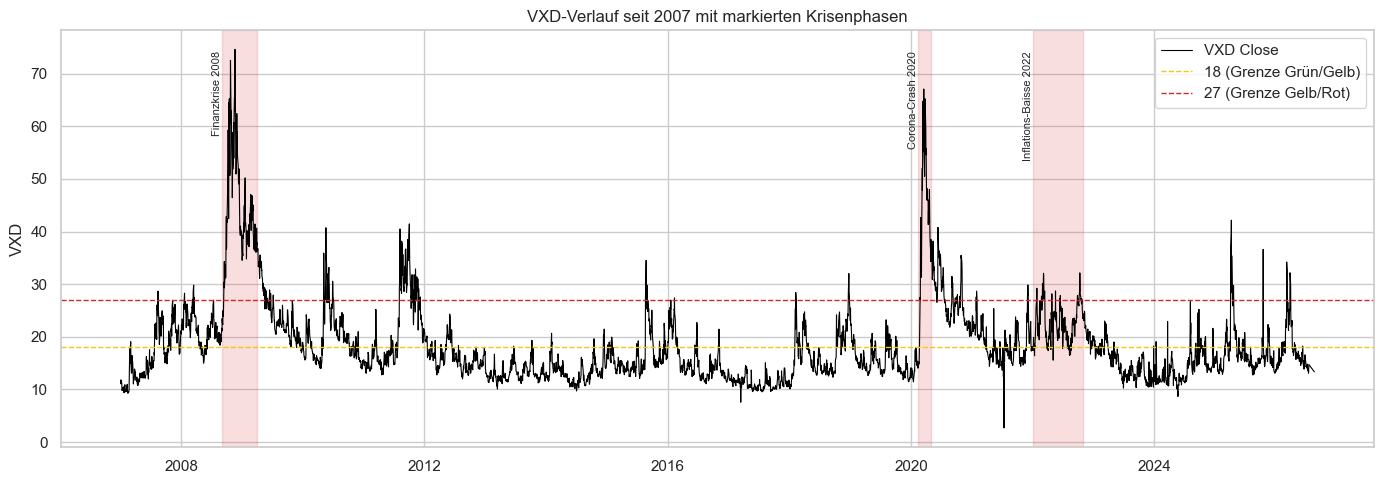

In [6]:
crisis_periods = {
    "Finanzkrise 2008": ("2008-09-01", "2009-03-31"),
    "Corona-Crash 2020": ("2020-02-15", "2020-04-30"),
    "Inflations-Baisse 2022": ("2022-01-01", "2022-10-31"),
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vxd_close"], color="black", linewidth=0.8, label="VXD Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)
    ax.text(pd.Timestamp(start), ax.get_ylim()[1] * 0.95, label, fontsize=8, rotation=90,
            va="top", ha="right")

ax.axhline(VXD_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", linewidth=1,
           label=f"{VXD_THRESHOLD_GELB} (Grenze Grün/Gelb)")
ax.axhline(VXD_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
           label=f"{VXD_THRESHOLD_ROT} (Grenze Gelb/Rot)")
ax.set_title("VXD-Verlauf seit 2007 mit markierten Krisenphasen")
ax.set_ylabel("VXD")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


Auswertbare Tage - Baseline: 4882, >18: 1850, >27: 471
         Rend. Baseline Rend. >18 Rend. >27 MaxDD Baseline MaxDD >18 MaxDD >27
Horizont                                                                      
5T               +0.18%    +0.32%    +0.49%         -1.55%    -2.28%    -3.62%
10T              +0.35%    +0.56%    +0.68%         -2.52%    -3.59%    -5.64%
15T              +0.52%    +0.82%    +1.04%         -3.25%    -4.50%    -6.93%
30T              +1.02%    +1.76%    +2.62%         -4.92%    -6.29%    -8.95%


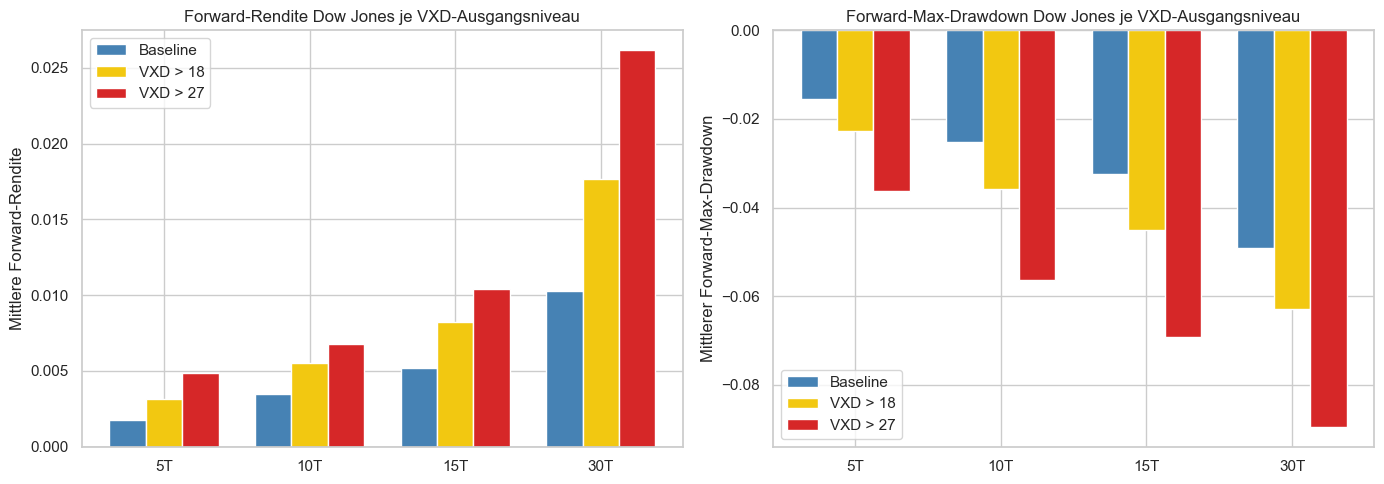

In [7]:
# Quantitative Ergänzung: Wie entwickelt sich der Dow Jones nach Tagen mit erhöhtem
# VXD? Verglichen werden erhöhte Niveaus (VXD > 18 bzw. VXD > 27)
# mit der unbedingten Baseline (alle Handelstage).
maske_gelb = df["vxd_close"] > VXD_THRESHOLD_GELB
maske_rot = df["vxd_close"] > VXD_THRESHOLD_ROT

zeilen_h1 = []
for h in HORIZONS:
    fr_base, mdd_base, n_base = forward_kennzahlen(ALL_DAYS, h)
    fr_g, mdd_g, n_g = forward_kennzahlen(maske_gelb, h)
    fr_r, mdd_r, n_r = forward_kennzahlen(maske_rot, h)
    zeilen_h1.append({
        "Horizont": f"{h}T",
        "Rend. Baseline": fr_base, "Rend. >18": fr_g, "Rend. >27": fr_r,
        "MaxDD Baseline": mdd_base, "MaxDD >18": mdd_g, "MaxDD >27": mdd_r,
    })
tab_h1 = pd.DataFrame(zeilen_h1).set_index("Horizont")

disp_h1 = tab_h1.copy()
for spalte in disp_h1.columns:
    disp_h1[spalte] = tab_h1[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Tage - Baseline: {n_base}, >18: {n_g}, >27: {n_r}")
print(disp_h1.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.25
ax_r.bar(x - w, tab_h1["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.bar(x,     tab_h1["Rend. >18"],  w, label="VXD > 18", color=COLOR_YELLOW)
ax_r.bar(x + w, tab_h1["Rend. >27"],  w, label="VXD > 27", color=COLOR_RED)
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite Dow Jones je VXD-Ausgangsniveau")
ax_r.legend()

ax_d.bar(x - w, tab_h1["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.bar(x,     tab_h1["MaxDD >18"],  w, label="VXD > 18", color=COLOR_YELLOW)
ax_d.bar(x + w, tab_h1["MaxDD >27"],  w, label="VXD > 27", color=COLOR_RED)
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown Dow Jones je VXD-Ausgangsniveau")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Der VXD bewegt sich den überwiegenden Teil der Zeit unterhalb
von 18 und schießt in den markierten Krisenphasen sichtbar über 27. Die
Ausgangshypothese eines ruhigen Normalzustands mit seltenen, aber massiven
Ausschlägen wird damit klar bestätigt.

**Ergänzung – Forward-Kennzahlen des Dow Jones:** Ein erhöhter VXD ist historisch
kein Verkaufssignal. Nach Tagen mit VXD > 27 lag die mittlere Forward-Rendite
des Dow Jones über 30 Tage bei +2,62 % und damit über
der Baseline (+1,02 %). Der Weg dorthin ist jedoch riskanter: Der
mittlere Forward-Max-Drawdown vertieft sich über 30 Tage von −4,92 %
(Baseline) auf −8,95 % (VXD > 27). Der VXD misst also Risiko und
Schwankungsbreite, nicht die Richtung.

**Praxisrelevanz für das Ampelsystem:** Die Grafik liefert die Grundlegitimation,
den VXD als Kernindikator einer Dow Jones-Ampel zu verwenden. Die Forward-Kennzahlen
schärfen die Lesart: Rot bedeutet „erhöhtes Schwankungs- und Drawdown-Risiko",
nicht „Kurse fallen sicher" – die Ampel steuert das Risiko, nicht die
Renditeerwartung.

### 4.2 H2 – VXD vs. Dow Jones-Renditen

**Hypothese:** Hohe VXD-Werte bzw. -Anstiege gehen mit negativen/volatilen
Dow Jones-Renditen einher (inverse Beziehung). Untersucht wird der Zusammenhang
zwischen (a) der täglichen VXD-Veränderung und (b) dem VXD-Niveau jeweils
gegenüber der Dow Jones-Tagesrendite (Pearson-Korrelation, Streudiagramme).


Korrelation VXD-Tagesänderung vs. Dow Jones-Tagesrendite: -0.696
Korrelation VXD-Niveau vs. Dow Jones-Tagesrendite: -0.126


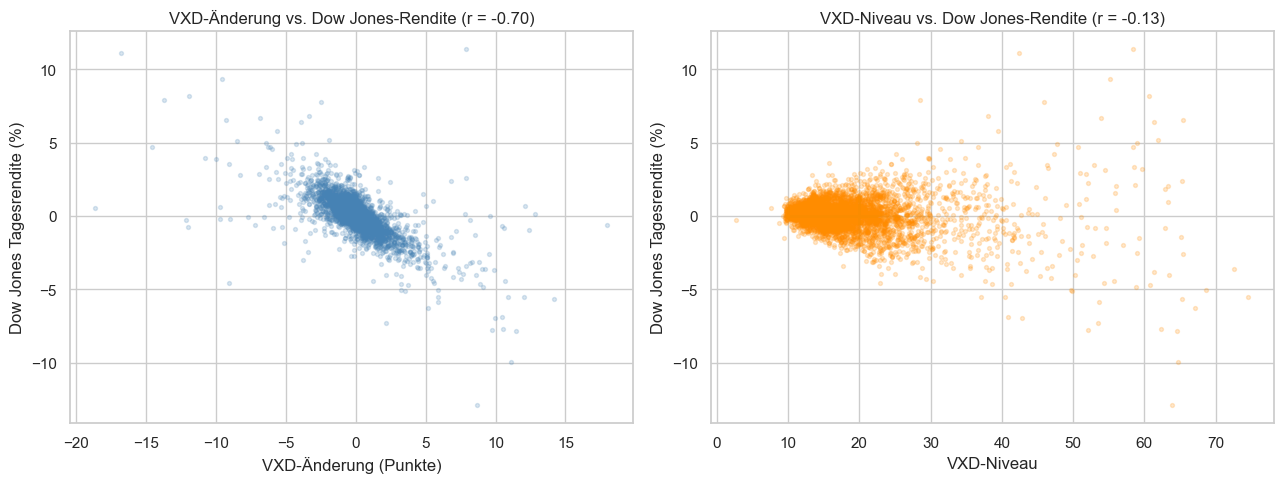

In [8]:
corr_change = df[["vxd_change", "dow_return"]].corr().iloc[0, 1]
corr_level = df[["vxd_close", "dow_return"]].corr().iloc[0, 1]
print(f"Korrelation VXD-Tagesänderung vs. Dow Jones-Tagesrendite: {corr_change:.3f}")
print(f"Korrelation VXD-Niveau vs. Dow Jones-Tagesrendite: {corr_level:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["vxd_change"], df["dow_return"], alpha=0.2, s=8, color="steelblue")
axes[0].set_xlabel("VXD-Änderung (Punkte)")
axes[0].set_ylabel("Dow Jones Tagesrendite (%)")
axes[0].set_title(f"VXD-Änderung vs. Dow Jones-Rendite (r = {corr_change:.2f})")

axes[1].scatter(df["vxd_close"], df["dow_return"], alpha=0.2, s=8, color="darkorange")
axes[1].set_xlabel("VXD-Niveau")
axes[1].set_ylabel("Dow Jones Tagesrendite (%)")
axes[1].set_title(f"VXD-Niveau vs. Dow Jones-Rendite (r = {corr_level:.2f})")

plt.tight_layout()
plt.show()

**Ergebnis:** Die tägliche VXD-Veränderung ist stark invers mit der
Dow Jones-Tagesrendite korreliert (r = −0,696) – steigt der VXD
deutlich, fällt der Index am selben Tag fast immer. Das reine VXD-Niveau sagt
dagegen kaum etwas über die Tagesrendite aus (r = −0,125).

**Praxisrelevanz für das Ampelsystem:** Der VXD eignet sich als
Zustandsindikator („wie angespannt ist der Markt"), nicht als Renditeprognose.
Rot heißt „erhöhte Vorsicht", nicht „der Markt fällt heute".

### 4.3 H3 – Volatility Clustering (Autokorrelation)

**Hypothese:** Der VXD zeigt Volatility Clustering, d. h. hohe bzw. niedrige
Werte treten in Clustern auf statt zufällig zu springen. Gemessen wird die
Autokorrelation des VXD-Niveaus für Lags von 1 bis 20 Handelstagen – relevant
für die Stabilität einer täglichen Ampel.


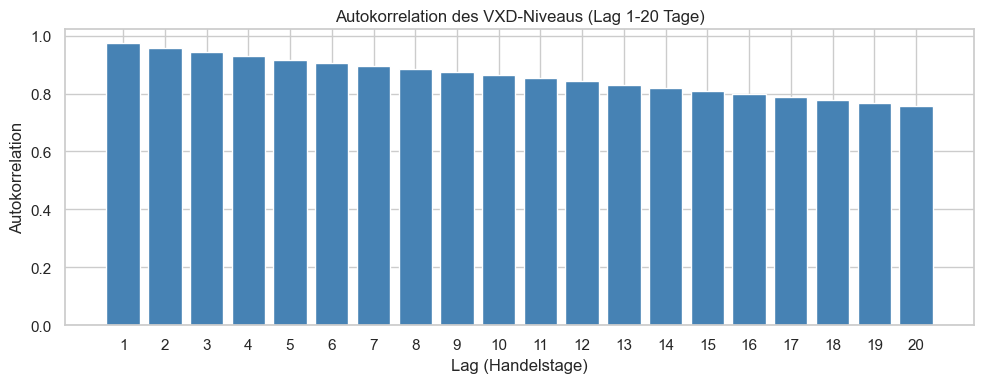

Autokorrelation Lag 1 (Vortag): 0.973
Autokorrelation Lag 5 (Vorwoche): 0.917


In [9]:
from pandas.plotting import autocorrelation_plot

lags = range(1, 21)
autocorrs = [df["vxd_close"].autocorr(lag) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, autocorrs, color="steelblue")
ax.set_xlabel("Lag (Handelstage)")
ax.set_ylabel("Autokorrelation")
ax.set_title("Autokorrelation des VXD-Niveaus (Lag 1-20 Tage)")
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

print(f"Autokorrelation Lag 1 (Vortag): {df['vxd_close'].autocorr(1):.3f}")
print(f"Autokorrelation Lag 5 (Vorwoche): {df['vxd_close'].autocorr(5):.3f}")

**Ergebnis:** Die Autokorrelation des VXD ist sowohl auf Tages-
(Lag 1: 0,973) als auch auf Wochensicht (Lag 5: 0,917)
extrem hoch. Der VXD ist damit ausgeprägt träge: ein hoher Wert heute macht
einen hohen Wert morgen sehr wahrscheinlich.

**Praxisrelevanz für das Ampelsystem:** Diese Trägheit ist für eine tägliche
Ampel ein Vorteil – die Farbe „flackert" nicht, sondern entwickelt sich stabil
über mehrere Tage. Das erhöht Glaubwürdigkeit und Akzeptanz des Signals.

### 4.4 H4 – Verteilung des VXD und Ampel-Schwellenwerte

**Hypothese:** Anhand der historischen Verteilung (Quantile) lassen sich
plausible Schwellenwerte für Grün/Gelb/Rot ableiten. Da der VXD ein anderes
typisches Niveau als der VIX hat, werden die Schwellen **nicht** von den
VIX-Faustregeln 20/30 übernommen, sondern so aus der VXD-Verteilung bestimmt,
dass sich vergleichbare Ampel-Anteile wie beim VIX (rund 64 % Grün / 27 % Gelb /
9 % Rot) ergeben. Geprüft wird, welcher Anteil der Handelstage in welche
Ampelphase fällt.


VXD-Quantile:
0.50    16.21
0.70    19.67
0.75    20.97
0.80    22.26
0.90    26.78
0.95    33.31
0.99    52.01
Name: vxd_close, dtype: float64


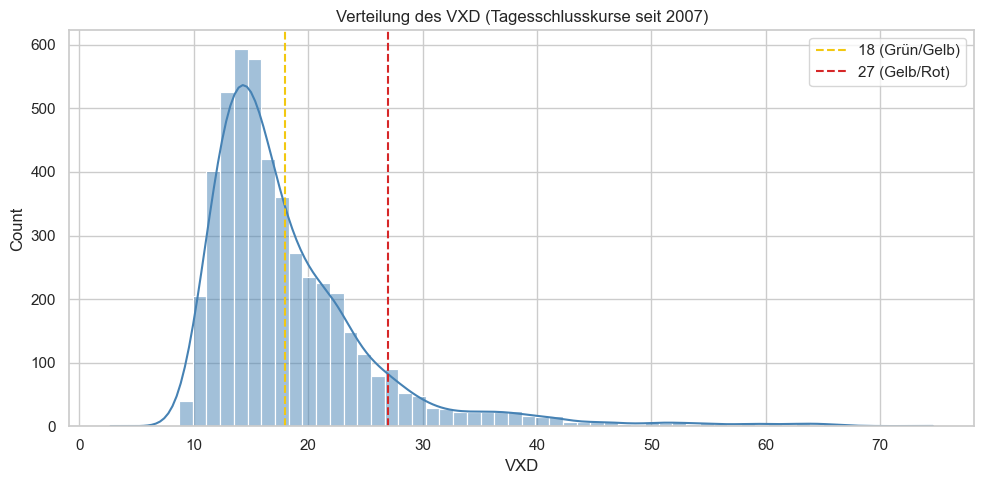

Grün (<18): 62.3% der Handelstage
Gelb (18-27): 28.2% der Handelstage
Rot (>27): 9.6% der Handelstage


In [10]:
quantiles = df["vxd_close"].quantile([0.5, 0.7, 0.75, 0.8, 0.9, 0.95, 0.99])
print("VXD-Quantile:")
print(quantiles.round(2))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["vxd_close"], bins=60, kde=True, ax=ax, color="steelblue")
ax.axvline(VXD_THRESHOLD_GELB, color=COLOR_YELLOW, linestyle="--", label=f"{VXD_THRESHOLD_GELB} (Grün/Gelb)")
ax.axvline(VXD_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", label=f"{VXD_THRESHOLD_ROT} (Gelb/Rot)")
ax.set_title("Verteilung des VXD (Tagesschlusskurse seit 2007)")
ax.set_xlabel("VXD")
ax.legend()
plt.tight_layout()
plt.show()

grenzen = [(0, VXD_THRESHOLD_GELB, f"Grün (<{VXD_THRESHOLD_GELB})"),
           (VXD_THRESHOLD_GELB, VXD_THRESHOLD_ROT, f"Gelb ({VXD_THRESHOLD_GELB}-{VXD_THRESHOLD_ROT})"),
           (VXD_THRESHOLD_ROT, np.inf, f"Rot (>{VXD_THRESHOLD_ROT})")]
for low, high, label in grenzen:
    share = ((df["vxd_close"] >= low) & (df["vxd_close"] < high)).mean() * 100
    print(f"{label}: {share:.1f}% der Handelstage")


**Ergebnis:** Die VXD-Verteilung ist rechtsschief (Median 16,2
unter Mittelwert 18,4). Die datenbasiert gewählten Schwellen
**18** und **27** teilen die Handelstage in 62,2 % Grün,
28,2 % Gelb und 9,6 % Rot – nahezu die gleichen Anteile wie
beim VIX (64 % / 27 % / 9 %) mit seinen Faustregeln 20/30. Die Perzentile
(50/75/90/95 = 16,2 / 21,0 / 26,8 /
33,3) stützen die Wahl: Die Grün/Gelb-Grenze 18 liegt nahe dem
75. Perzentil, die Rot-Grenze 27 nahe dem 90. Perzentil.

**Praxisrelevanz für das Ampelsystem:** Weil der VXD ein anderes Kursniveau
als der VIX hat, wären die VIX-Werte 20/30 hier ungeeignet gewesen. Die
datenbasierte Herleitung liefert VXD-eigene Schwellen mit vergleichbarer
Alarmhäufigkeit: Der Rot-Anteil von 9,6 % zeigt, wie oft die Routine
Alarm schlagen würde – selten genug, um „Alarm-Fatigue" zu vermeiden.

### 4.5 H5 – Dauer der Ampelphasen

**Hypothese:** Mit den datenbasierten Schwellen 18/27 wird jeder
Handelstag in Grün/Gelb/Rot klassifiziert; anschließend werden zusammenhängende
Phasen identifiziert und ihre Dauer ausgewertet – wichtig, um einzuschätzen, ob
die Ampel stabil genug für eine tägliche Routine ist.


In [11]:
def ampel(vxd_value: float) -> str:
    if vxd_value < VXD_THRESHOLD_GELB:
        return "grün"
    elif vxd_value < VXD_THRESHOLD_ROT:
        return "gelb"
    return "rot"

df["ampel"] = df["vxd_close"].apply(ampel)

phase_id = (df["ampel"] != df["ampel"].shift()).cumsum().rename("phase_id")
phases = df.groupby(phase_id).agg(
    ampel=("ampel", "first"),
    start=("ampel", lambda s: s.index[0]),
    ende=("ampel", lambda s: s.index[-1]),
    dauer_tage=("ampel", "size"),
)

print("Anzahl Phasenwechsel gesamt:", len(phases))
print("\nDurchschnittliche Phasendauer (Handelstage) je Ampelfarbe:")
print(phases.groupby("ampel")["dauer_tage"].describe()[["count", "mean", "50%", "max"]])

print("\nDie 5 längsten Rot-Phasen:")
print(phases[phases["ampel"] == "rot"].sort_values("dauer_tage", ascending=False).head())


Anzahl Phasenwechsel gesamt: 430

Durchschnittliche Phasendauer (Handelstage) je Ampelfarbe:
       count       mean  50%    max
ampel                              
gelb   214.0   6.462617  2.0   72.0
grün   158.0  19.354430  4.5  311.0
rot     58.0   8.120690  2.0  168.0

Die 5 längsten Rot-Phasen:
         ampel      start       ende  dauer_tage
phase_id                                        
35         rot 2008-09-15 2009-05-15         168
233        rot 2020-02-25 2020-06-03          70
105        rot 2011-08-04 2011-10-13          50
235        rot 2020-06-08 2020-07-17          29
65         rot 2010-05-14 2010-05-26           9


**Ergebnis:** Über den Zeitraum gab es 430 Phasenwechsel.
Rot-Phasen sind meist kurz (Median 2 Handelstage), können in
echten Krisen aber lange dauern (längste Phase 168 Tage). Mittelwert
(8,1) und Median (2) klaffen stark
auseinander – Rot ist meist ein kurzer Warnblinker, selten ein Dauerzustand.

**Praxisrelevanz für das Ampelsystem:** Ein einzelner Rot-Tag sollte keine
drastische Reaktion auslösen, da er statistisch meist nach wenigen Tagen abklingt.
Eine Eskalationsregel („Rot an 3+ Tagen in Folge = erhöhte Warnstufe") trennt
kurzfristiges Rauschen von echten Krisenphasen.

### 4.6 H6 – Neues 3-Monats-Hoch als Frühwarnsignal

**Hypothese:** Wenn der VXD ein neues 3-Monats-Hoch erreicht (höchster
Schlusskurs der vorangegangenen ca. 63 Handelstage), folgt in den nächsten
5 bzw. 10 Handelstagen überdurchschnittlich oft eine Phase mit VXD > 27.
Die Trefferquote wird mit der unbedingten Baseline verglichen.


In [12]:
# Rollierendes 3-Monats-Hoch VOR dem aktuellen Tag berechnen. shift(1) stellt sicher,
# dass der aktuelle Tag selbst nicht im Vergleichsfenster enthalten ist (kein Blick in die Zukunft).
WINDOW_3M = 63
rolling_high_3m = df["vxd_close"].shift(1).rolling(WINDOW_3M).max()

# Signaltage: aktueller Schlusskurs liegt über dem rollierenden 3-Monats-Hoch
new_3m_high = df["vxd_close"] > rolling_high_3m
print(f"Anzahl Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")

hit_rate_5 = forward_hit_rate(new_3m_high, horizon=5)
hit_rate_10 = forward_hit_rate(new_3m_high, horizon=10)
baseline_5 = forward_hit_rate(ALL_DAYS, horizon=5)
baseline_10 = forward_hit_rate(ALL_DAYS, horizon=10)

print(f"Trefferquote nach Signal, 5 Tage:  {hit_rate_5:.1%}  (Baseline: {baseline_5:.1%})")
print(f"Trefferquote nach Signal, 10 Tage: {hit_rate_10:.1%}  (Baseline: {baseline_10:.1%})")

Anzahl Signaltage (neues 3-Monats-Hoch): 159
Trefferquote nach Signal, 5 Tage:  42.1%  (Baseline: 13.1%)
Trefferquote nach Signal, 10 Tage: 44.7%  (Baseline: 16.0%)


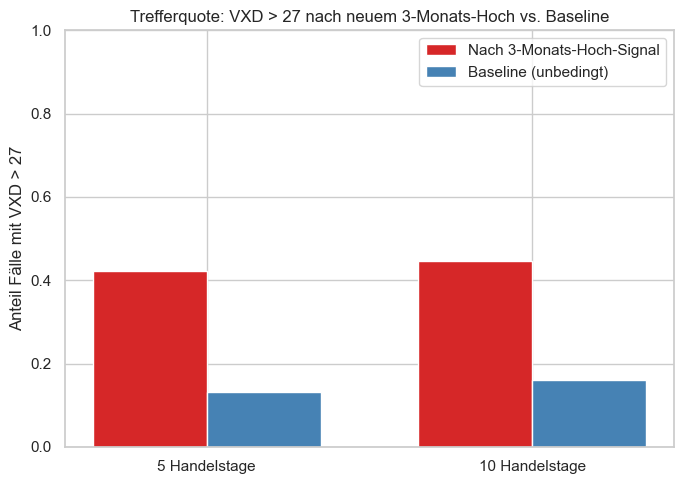

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["5 Handelstage", "10 Handelstage"]
signal_rates = [hit_rate_5, hit_rate_10]
baseline_rates = [baseline_5, baseline_10]
x = np.arange(len(labels))
width = 0.35

ax.bar(x - width / 2, signal_rates, width, label="Nach 3-Monats-Hoch-Signal", color=COLOR_RED)
ax.bar(x + width / 2, baseline_rates, width, label="Baseline (unbedingt)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel(f"Anteil Fälle mit VXD > {VXD_THRESHOLD_ROT}")
ax.set_ylim(0, 1)
ax.set_title("Trefferquote: VXD > 27 nach neuem 3-Monats-Hoch vs. Baseline")
ax.legend()
plt.tight_layout()
plt.show()

Signaltage (neues 3-Monats-Hoch): 159


         Trefferq. Signal Trefferq. Baseline Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                                                            
5T                  42.1%              13.1%       +0.78%         +0.18%       -2.85%         -1.55%
10T                 44.7%              16.0%       +0.66%         +0.35%       -4.53%         -2.52%
15T                 45.9%              18.5%       +1.08%         +0.52%       -5.40%         -3.25%
30T                 50.9%              24.8%       +2.47%         +1.02%       -6.99%         -4.92%


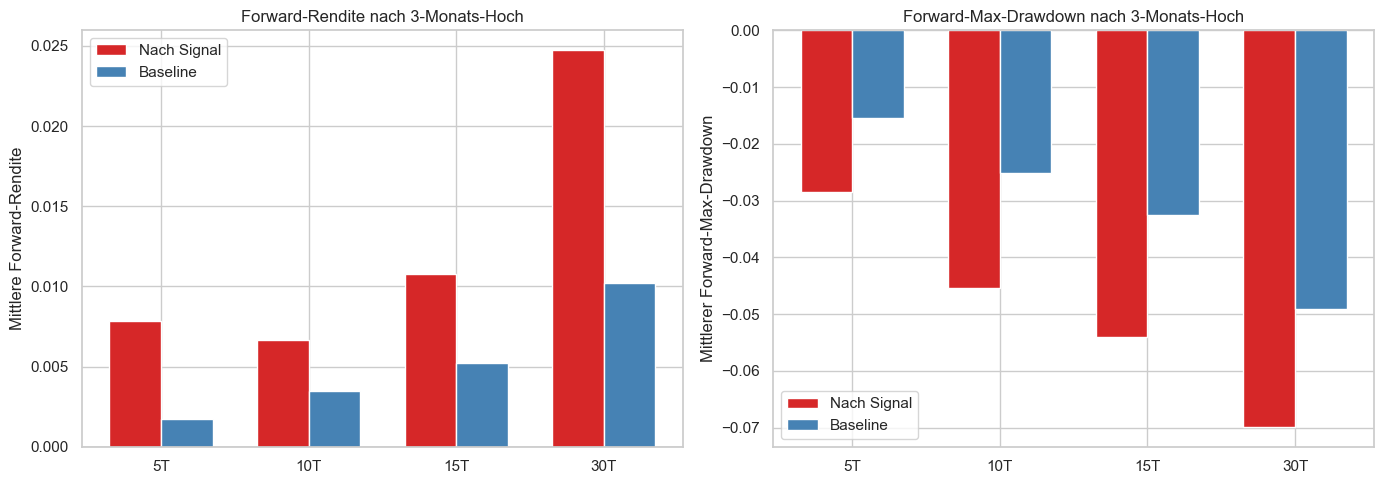

In [14]:
# Ergänzung: Forward-Rendite und Forward-Max-Drawdown des Dow Jones nach dem
# 3-Monats-Hoch-Signal, plus Erweiterung der Trefferquote auf alle Horizonte.
zeilen_h6 = []
for h in HORIZONS:
    hr_sig = forward_hit_rate(new_3m_high, horizon=h)
    hr_base = forward_hit_rate(ALL_DAYS, horizon=h)
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(new_3m_high, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h6.append({
        "Horizont": f"{h}T",
        "Trefferq. Signal": hr_sig, "Trefferq. Baseline": hr_base,
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h6 = pd.DataFrame(zeilen_h6).set_index("Horizont")

disp_h6 = tab_h6.copy()
for spalte in ["Trefferq. Signal", "Trefferq. Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:.1%}")
for spalte in ["Rend. Signal", "Rend. Baseline", "MaxDD Signal", "MaxDD Baseline"]:
    disp_h6[spalte] = tab_h6[spalte].map(lambda x: f"{x:+.2%}")
print(f"Signaltage (neues 3-Monats-Hoch): {int(new_3m_high.sum())}")
print(disp_h6.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h6["Rend. Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_r.bar(x + w/2, tab_h6["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Monats-Hoch")
ax_r.legend()
ax_d.bar(x - w/2, tab_h6["MaxDD Signal"], w, label="Nach Signal", color=COLOR_RED)
ax_d.bar(x + w/2, tab_h6["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Monats-Hoch")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Über den Beobachtungszeitraum gab es 159 neue
3-Monats-Hochs. Nach einem solchen Signal lag der VXD in 42,1 %
(5 Tage) bzw. 44,7 % (10 Tage) der Fälle mindestens einmal über
27 – gegenüber einer Baseline von 13,1 % / 16,0 %.
Über die längeren Horizonte bleibt der Abstand bestehen (15/30 Tage:
45,9 % / 50,9 % gegenüber 18,5 % /
24,8 %). Das Signal erhöht die Trefferquote also robust, bleibt
aber ein Minderheits-Ereignis.

**Ergänzung – Forward-Kennzahlen des Dow Jones:** Wie in 4.1 markiert das Signal
erhöhtes Risiko, keine fallenden Kurse. Die mittlere Forward-Rendite nach dem
3-Monats-Hoch liegt über 30 Tage bei +2,47 % (über
Baseline +1,02 %), der Forward-Max-Drawdown fällt jedoch tiefer aus
(30 Tage: −6,99 % gegenüber −4,92 %). Das neue
3-Monats-Hoch kündigt somit vor allem eine turbulentere, im Mittel aber positiv
driftende Phase an.

**Praxisrelevanz für das Ampelsystem:** Ein neues 3-Monats-Hoch eignet sich als
zusätzliches „Vorsicht"-Flag, das bereits vor Erreichen der Rot-Schwelle
anschlägt – als kleines Warnsymbol neben der Hauptampel. Es warnt vor erhöhter
Schwankung und tieferen Rücksetzern, nicht vor einem Renditeeinbruch.

### 4.7 H7 – „3-Punkte-Umkehr“ als Beruhigungssignal

**Hypothese:** An Tagen mit Open ≥ 18 UND Intraday-High > Open UND
(Intraday-High − Close) ≥ 3 schießt der VXD im Tagesverlauf nach oben, gibt
den Anstieg bis Handelsschluss aber größtenteils wieder ab. Geprüft wird per
Event-Study, ob der VXD an den 5 Folgetagen im Schnitt fällt (= Beruhigung).


In [15]:
# Signal-Definition: ausgeprägte Intraday-Umkehr im VXD
#   - Open >= 18          -> Markt startet bereits angespannt (Gelb-Niveau)
#   - High > Open             -> im Tagesverlauf zieht der VXD weiter an
#   - (High - Close) >= 3     -> der Tag schließt aber mindestens 3 Punkte unter dem Hoch
vxd_ohlc = vxd[["Open", "High", "Low", "Close"]].reindex(df.index)

reversal_signal = (
    (vxd_ohlc["Open"] >= VXD_THRESHOLD_GELB)
    & (vxd_ohlc["High"] > vxd_ohlc["Open"])
    & ((vxd_ohlc["High"] - vxd_ohlc["Close"]) >= 3)
)
signal_dates = df.index[reversal_signal.values]
print(f"Anzahl '3-Punkte-Umkehr'-Signale: {len(signal_dates)}")

HORIZON_H2 = 5
vxd_close_values = df["vxd_close"]
paths = []
for date in signal_dates:
    pos = df.index.get_loc(date)
    if pos + HORIZON_H2 >= len(df):
        continue
    base = vxd_close_values.iloc[pos]
    path = vxd_close_values.iloc[pos : pos + HORIZON_H2 + 1].values - base
    paths.append(path)
paths = np.array(paths)

mean_path = paths.mean(axis=0)
median_path = np.median(paths, axis=0)
share_falling = (paths[:, -1] < 0).mean()

print(f"Auswertbare Signale: {len(paths)}")
print(f"Durchschnittliche VXD-Änderung nach {HORIZON_H2} Tagen: {mean_path[-1]:+.2f} Punkte")
print(f"Median VXD-Änderung nach {HORIZON_H2} Tagen:            {median_path[-1]:+.2f} Punkte")
print(f"Anteil Fälle mit niedrigerem VXD nach {HORIZON_H2} Tagen: {share_falling:.1%}")


Anzahl '3-Punkte-Umkehr'-Signale: 486
Auswertbare Signale: 486
Durchschnittliche VXD-Änderung nach 5 Tagen: -0.89 Punkte
Median VXD-Änderung nach 5 Tagen:            -1.20 Punkte
Anteil Fälle mit niedrigerem VXD nach 5 Tagen: 65.4%


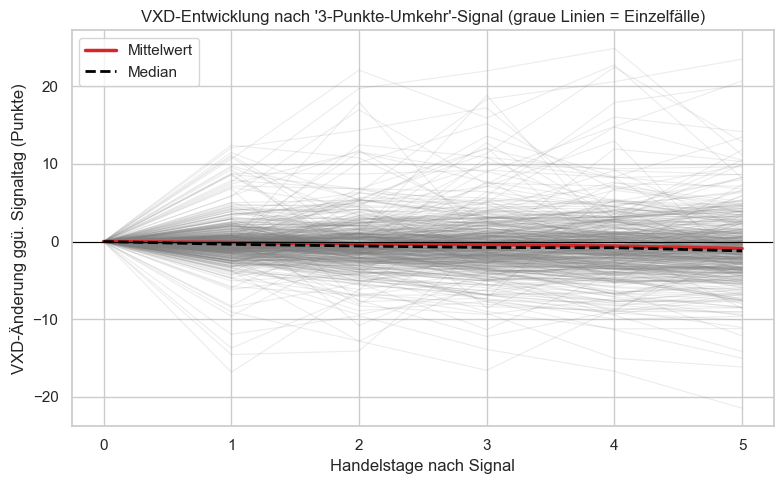

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
days = np.arange(0, HORIZON_H2 + 1)
for path in paths:
    ax.plot(days, path, color="grey", alpha=0.15, linewidth=0.8)
ax.plot(days, mean_path, color=COLOR_RED, linewidth=2.5, label="Mittelwert")
ax.plot(days, median_path, color="black", linewidth=2, linestyle="--", label="Median")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Handelstage nach Signal")
ax.set_ylabel("VXD-Änderung ggü. Signaltag (Punkte)")
ax.set_title("VXD-Entwicklung nach '3-Punkte-Umkehr'-Signal (graue Linien = Einzelfälle)")
ax.legend()
plt.tight_layout()
plt.show()

Auswertbare Signaltage: 486
         Rend. Signal Rend. Baseline MaxDD Signal MaxDD Baseline
Horizont                                                        
5T             +0.33%         +0.18%       -2.35%         -1.55%
10T            +0.58%         +0.35%       -3.71%         -2.52%
15T            +0.81%         +0.52%       -4.73%         -3.25%
30T            +1.95%         +1.02%       -6.55%         -4.92%


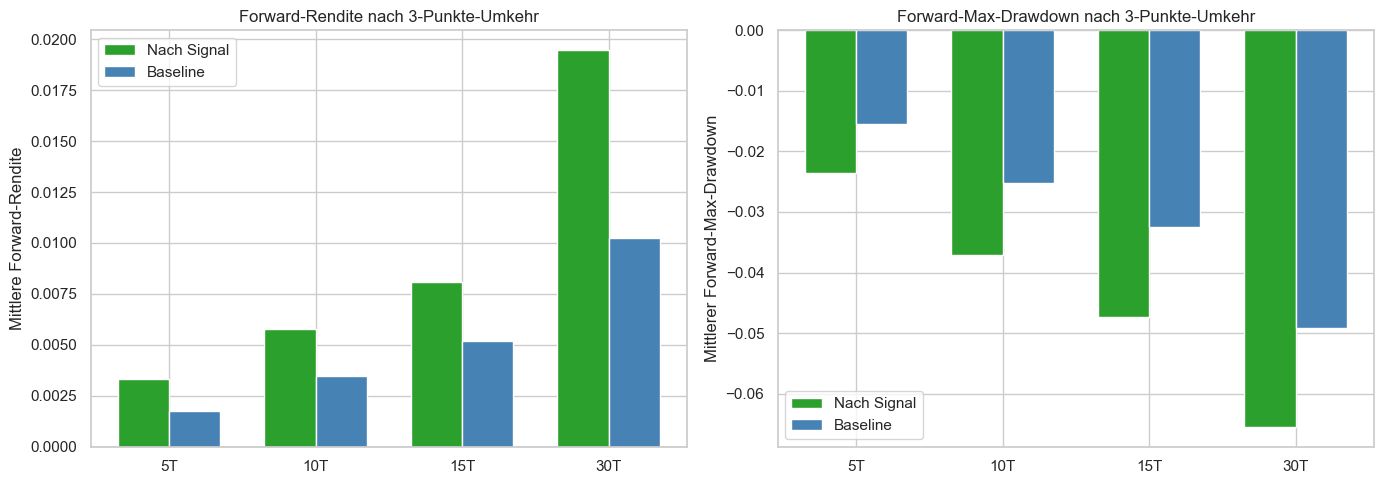

In [17]:
# Ergänzung: Das Umkehr-Signal wird zusätzlich als Renditesignalgeber für den
# Dow Jones ausgewertet (Forward-Rendite und Forward-Max-Drawdown), im Vergleich
# zur Baseline. Die VXD-eigene Beruhigungs-Auswertung oben bleibt bestehen.
zeilen_h7 = []
for h in HORIZONS:
    fr_sig, mdd_sig, n_sig = forward_kennzahlen(reversal_signal, h)
    fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, h)
    zeilen_h7.append({
        "Horizont": f"{h}T",
        "Rend. Signal": fr_sig, "Rend. Baseline": fr_base,
        "MaxDD Signal": mdd_sig, "MaxDD Baseline": mdd_base,
    })
tab_h7 = pd.DataFrame(zeilen_h7).set_index("Horizont")

disp_h7 = tab_h7.copy()
for spalte in disp_h7.columns:
    disp_h7[spalte] = tab_h7[spalte].map(lambda x: f"{x:+.2%}")
print(f"Auswertbare Signaltage: {n_sig}")
print(disp_h7.to_string())

fig, (ax_r, ax_d) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(HORIZONS)); w = 0.35
ax_r.bar(x - w/2, tab_h7["Rend. Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_r.bar(x + w/2, tab_h7["Rend. Baseline"], w, label="Baseline", color="steelblue")
ax_r.axhline(0, color="black", linewidth=0.8)
ax_r.set_xticks(x); ax_r.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_r.set_ylabel("Mittlere Forward-Rendite")
ax_r.set_title("Forward-Rendite nach 3-Punkte-Umkehr")
ax_r.legend()
ax_d.bar(x - w/2, tab_h7["MaxDD Signal"], w, label="Nach Signal", color=COLOR_GREEN)
ax_d.bar(x + w/2, tab_h7["MaxDD Baseline"], w, label="Baseline", color="steelblue")
ax_d.set_xticks(x); ax_d.set_xticklabels([f"{h}T" for h in HORIZONS])
ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
ax_d.set_title("Forward-Max-Drawdown nach 3-Punkte-Umkehr")
ax_d.legend()
plt.tight_layout(); plt.show()


**Ergebnis:** Von 486 „3-Punkte-Umkehr"-Signalen fiel der VXD
in 65,4 % der Fälle innerhalb von 5 Handelstagen unter den
Stand des Signaltags, im Schnitt um −0,89 Punkte (Median
−1,20). Die Beruhigungs-Hypothese wird tendenziell bestätigt
(rund zwei von drei Fällen), ist aber kein Automatismus.

**Ergänzung – der Dow Jones als Renditesignal:** Wertet man das Signal als
Renditesignalgeber für den Index aus, liegt die Forward-Rendite über 30 Tage bei
+1,95 % und damit leicht über der Baseline (+1,02 %).
Der Pfad bleibt schwankungsanfällig – der Forward-Max-Drawdown ist mit
−6,55 % tiefer als die Baseline (−4,92 %). Die
VXD-Beruhigung ersetzt also kein aktives Risikomanagement.

**Praxisrelevanz für das Ampelsystem:** Das Signal eignet sich als
Entwarnungs-Hinweis innerhalb einer Gelb-/Rot-Phase („mögliche nahende
Beruhigung, historisch ca. 2 von 3 Fällen"), ohne einen neuen Ampelzustand zu
erzeugen.

### 4.8 H8 – VXD-Schwellenwerte anhand Verteilung und Stressphasen

**Hypothese:** Der VXD hebt sich während bekannter Stressphasen ab einem
bestimmten Niveau sichtbar vom Normalzustand ab. Verglichen werden die
Perzentile der Gesamtverteilung (50/75/90/95) mit Median, Minimum und Maximum
des VXD innerhalb und außerhalb der Krisenphasen, um die Gelb-/Rot-Schwellen
datenbasiert zu validieren.


In [18]:
percentiles_h3 = df["vxd_close"].quantile([0.50, 0.75, 0.90, 0.95])
print("VXD-Perzentile (gesamter Zeitraum):")
print(percentiles_h3.round(2))

# Boolesche Maske: Tag liegt innerhalb einer der definierten Stressphasen
in_crisis = pd.Series(False, index=df.index)
for start, end in crisis_periods.values():
    in_crisis |= (df.index >= start) & (df.index <= end)

print("\nVXD während Stressphasen (Median / Min / Max):")
print(df.loc[in_crisis, "vxd_close"].agg(["median", "min", "max"]).round(2))
print("\nVXD außerhalb von Stressphasen (Median / Min / Max):")
print(df.loc[~in_crisis, "vxd_close"].agg(["median", "min", "max"]).round(2))

VXD-Perzentile (gesamter Zeitraum):
0.50    16.21
0.75    20.97
0.90    26.78
0.95    33.31
Name: vxd_close, dtype: float64

VXD während Stressphasen (Median / Min / Max):
median    27.49
min       14.88
max       74.60
Name: vxd_close, dtype: float64

VXD außerhalb von Stressphasen (Median / Min / Max):
median    15.71
min        2.71
max       42.16
Name: vxd_close, dtype: float64


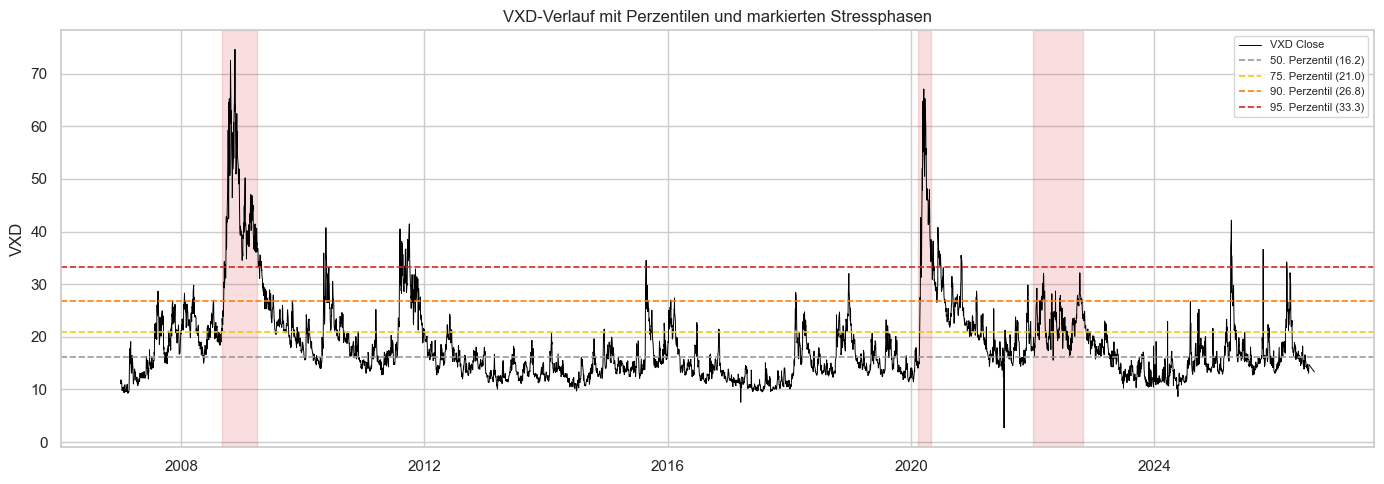

In [19]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["vxd_close"], color="black", linewidth=0.7, label="VXD Close")

for label, (start, end) in crisis_periods.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLOR_RED, alpha=0.15)

percentile_colors = ["#999999", COLOR_YELLOW, "#ff7f0e", COLOR_RED]
for (q, val), color in zip(percentiles_h3.items(), percentile_colors):
    ax.axhline(val, linestyle="--", linewidth=1.2, color=color,
               label=f"{int(q * 100)}. Perzentil ({val:.1f})")

ax.set_title("VXD-Verlauf mit Perzentilen und markierten Stressphasen")
ax.set_ylabel("VXD")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Ergebnis:** Der Median-VXD während der markierten Stressphasen
(27,5) liegt nahe am 90. Perzentil der Gesamtverteilung
(26,8) und deutlich über dem 75. Perzentil (21,0). Die
Rot-Schwelle 27 ist damit datenbasiert gut gedeckt, Gelb verortet sich im
Bereich 75.–90. Perzentil (ca. 21–27).
Dass der Maximalwert außerhalb der Phasen (42,2) hoch ist,
zeigt zugleich, dass die grob nach Kalenderdatum definierten Fenster nicht
trennscharf sind.

**Praxisrelevanz für das Ampelsystem:** Dieser Abschnitt belegt datenbasiert,
dass die VXD-Schwellen (Grün < 18, Gelb 18–27, Rot > 27) nicht
willkürlich sind, sondern sich an historischen Perzentilen und realem
Krisenverhalten orientieren.

### 4.9 H9 – Divergenz zum Index als Frühindikator

**Hypothese:** VXD und Dow Jones sind normalerweise invers korreliert (vgl. 4.2).
Ein hoher Anteil an Tagen mit untypischem Gleichlauf (beide steigen gleichzeitig)
in einem rollierenden Fenster könnte nachfolgende Marktturbulenzen ankündigen.
Als Turbulenz-Definition dient konsistent zu 4.6: VXD > 27 in den nächsten
10 Handelstagen.


In [20]:
# Tage, an denen Dow Jones UND VXD am selben Tag gleichzeitig gestiegen sind
co_up = (df["dow_return"] > 0) & (df["vxd_change"] > 0)

share_5d = co_up.rolling(5).mean()
share_10d = co_up.rolling(10).mean()

DIVERGENCE_THRESHOLD = 0.6
high_divergence_5d = share_5d > DIVERGENCE_THRESHOLD

print(f"Tage mit >{DIVERGENCE_THRESHOLD:.0%} Gleichlauf im 5-Tage-Fenster: "
      f"{int(high_divergence_5d.sum())} von {int(share_5d.notna().sum())} "
      f"({high_divergence_5d.mean():.1%})")

# Turbulenz-Wahrscheinlichkeit nach Divergenz-Signal vs. Baseline (baseline_10 aus Abschnitt 9.1,
# identische Definition: VXD > 27 in den nächsten 10 Handelstagen)
turbulence_after_divergence = forward_hit_rate(high_divergence_5d, horizon=10)

print(f"P(VXD > {VXD_THRESHOLD_ROT} in den nächsten 10 Tagen | Divergenz > {DIVERGENCE_THRESHOLD:.0%}): "
      f"{turbulence_after_divergence:.1%}")
print(f"P(VXD > {VXD_THRESHOLD_ROT} in den nächsten 10 Tagen), Baseline: {baseline_10:.1%}")

Tage mit >60% Gleichlauf im 5-Tage-Fenster: 6 von 4908 (0.1%)
P(VXD > 27 in den nächsten 10 Tagen | Divergenz > 60%): 50.0%
P(VXD > 27 in den nächsten 10 Tagen), Baseline: 16.0%


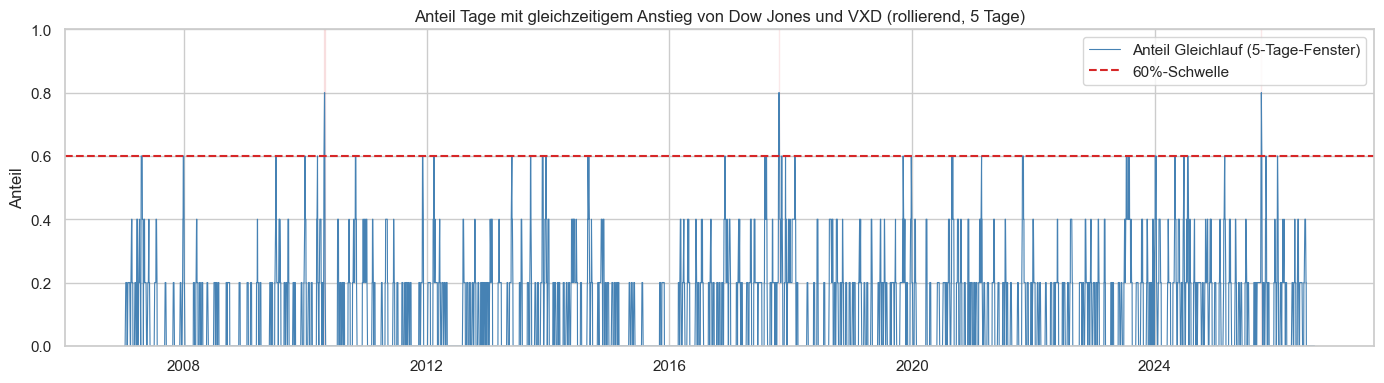

In [21]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, share_5d, color="steelblue", linewidth=0.8, label="Anteil Gleichlauf (5-Tage-Fenster)")
ax.axhline(DIVERGENCE_THRESHOLD, color=COLOR_RED, linestyle="--", label=f"{DIVERGENCE_THRESHOLD:.0%}-Schwelle")
ax.fill_between(df.index, 0, 1, where=high_divergence_5d.fillna(False).values, color=COLOR_RED, alpha=0.1)
ax.set_ylim(0, 1)
ax.set_title("Anteil Tage mit gleichzeitigem Anstieg von Dow Jones und VXD (rollierend, 5 Tage)")
ax.set_ylabel("Anteil")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Ergebnis:** Ein gleichzeitiger Anstieg von Dow Jones und VXD an mindestens
60 % der Tage eines 5-Tage-Fensters ist mit 6 von 4907
Fenstern extrem selten. In dieser strengen Form ist die Stichprobe statistisch
nicht belastbar (Trefferquote 50,0 % vs. Baseline 16,0 %).

**Praxisrelevanz für das Ampelsystem:** Vor einer Aufnahme in die Ampel muss die
Definition gelockert und mit mehr Fällen getestet werden – genau das leistet die
folgende systematische Rasteranalyse.

**Fortsetzung – systematischer Parameterraster:** Die Original-Definition
(5-Tage-Fenster, 60 %-Schwelle) liefert nur wenige Signale und ist statistisch
nicht belastbar. Daher wird der Divergenz-Ansatz über einen vollständig
gekreuzten Parameterraster geprüft und zugleich um die beiden Dow Jones-Kennzahlen
**Forward-Rendite** und **Forward-Max-Drawdown** ergänzt:

- **Vorhersagehorizont:** 10, 15, 30 Handelstage
- **Beobachtungsfenster** (rollierender Divergenz-Anteil): 10, 15, 30 Tage
- **Anteils-Schwelle** (ab wann ein Fenster als Signal zählt): 15 %, 20 %, 25 %
- **Anstiegstag:** Dow Jones-Tagesrendite ≥ 0,25 % **und** gleichzeitig steigender
  VXD. Die Schwelle 0,25 % liegt bewusst knapp oberhalb des Rauschens der
  Tagesrendite und bezieht sich auf den **Index**, nicht auf die VXD-Veränderung.

Das ergibt 3 × 3 × 3 = **27 Kombinationen**. Als Mindestkriterium für eine
belastbare Aussage (und damit für eine eigene Visualisierung) gelten
**mindestens 30 Signaltage**. Alle 27 Kombinationen erscheinen vollständig in
der Ergebnistabelle; separat visualisiert werden nur die belastbaren.


In [22]:
# Anstiegstag = Index-Tagesrendite >= 0,25 % UND gleichzeitig steigender VXD.
# (dow_return liegt in %, daher Schwelle 0.25; die Signifikanzschwelle bezieht
#  sich damit korrekt auf den Index und nicht auf die VXD-Veränderung.)
co_up_div = (df["dow_return"] >= 0.25) & (df["vxd_change"] > 0)

RASTER_HORIZONTE = [10, 15, 30]
RASTER_FENSTER = [10, 15, 30]
RASTER_LEVELS = [0.15, 0.20, 0.25]
MIN_SIGNALE = 30  # Mindestkriterium für Belastbarkeit und eigene Visualisierung

raster_zeilen = []
for fenster in RASTER_FENSTER:
    for level in RASTER_LEVELS:
        signal = co_up_div.rolling(fenster).mean() > level
        n_signale = int(signal.sum())
        for horizont in RASTER_HORIZONTE:
            hr = forward_hit_rate(signal, horizon=horizont)
            hr_base = forward_hit_rate(ALL_DAYS, horizon=horizont)
            fr, mdd, _ = forward_kennzahlen(signal, horizont)
            fr_base, mdd_base, _ = forward_kennzahlen(ALL_DAYS, horizont)
            raster_zeilen.append({
                "Fenster": fenster, "Schwelle": level, "Horizont": horizont,
                "Signale": n_signale,
                "Trefferquote": hr, "Trefferq_Baseline": hr_base,
                "Fwd_Rendite": fr, "Rendite_Baseline": fr_base,
                "Fwd_MaxDD": mdd, "MaxDD_Baseline": mdd_base,
                "belastbar": n_signale >= MIN_SIGNALE,
            })
raster = pd.DataFrame(raster_zeilen)
print(f"Kombinationen gesamt: {len(raster)} | "
      f"davon belastbar (>= {MIN_SIGNALE} Signale): {int(raster['belastbar'].sum())}")

disp_raster = pd.DataFrame({
    "Fenster": raster["Fenster"].astype(int).map(lambda x: f"{x}T"),
    "Schwelle": raster["Schwelle"].map(lambda x: f"{x:.0%}"),
    "Horizont": raster["Horizont"].astype(int).map(lambda x: f"{x}T"),
    "Signale": raster["Signale"].astype(int),
    "Trefferq.": raster["Trefferquote"].map(lambda x: f"{x:.1%}" if pd.notna(x) else "n/a"),
    "Baseline": raster["Trefferq_Baseline"].map(lambda x: f"{x:.1%}"),
    "Fwd-Rend.": raster["Fwd_Rendite"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "Rend-Base": raster["Rendite_Baseline"].map(lambda x: f"{x:+.2%}"),
    "Fwd-MaxDD": raster["Fwd_MaxDD"].map(lambda x: f"{x:+.2%}" if pd.notna(x) else "n/a"),
    "MaxDD-Base": raster["MaxDD_Baseline"].map(lambda x: f"{x:+.2%}"),
    "belastbar": raster["belastbar"].map(lambda x: "ja" if x else "nein"),
})
print(disp_raster.to_string(index=False))


Kombinationen gesamt: 27 | davon belastbar (>= 30 Signale): 24
Fenster Schwelle Horizont  Signale Trefferq. Baseline Fwd-Rend. Rend-Base Fwd-MaxDD MaxDD-Base belastbar
    10T      15%      10T      578     12.8%    16.0%    +0.26%    +0.35%    -2.39%     -2.52%        ja
    10T      15%      15T      578     15.6%    18.5%    +0.38%    +0.52%    -3.15%     -3.25%        ja
    10T      15%      30T      578     22.7%    24.8%    +0.96%    +1.02%    -4.57%     -4.92%        ja
    10T      20%      10T      135     11.9%    16.0%    -0.30%    +0.35%    -2.50%     -2.52%        ja
    10T      20%      15T      135     18.5%    18.5%    -0.47%    +0.52%    -3.40%     -3.25%        ja
    10T      20%      30T      135     24.4%    24.8%    +0.64%    +1.02%    -4.53%     -4.92%        ja
    10T      25%      10T      135     11.9%    16.0%    -0.30%    +0.35%    -2.50%     -2.52%        ja
    10T      25%      15T      135     18.5%    18.5%    -0.47%    +0.52%    -3.40%     -3.25%   

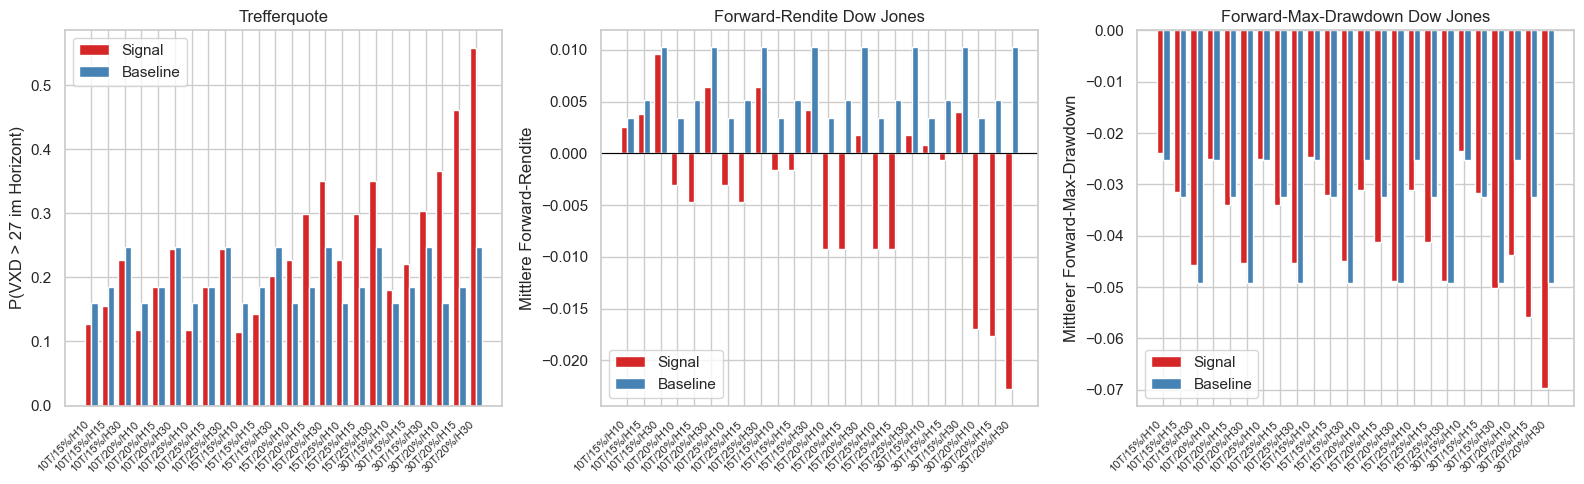

In [23]:
# Visualisierung nur für belastbare Kombinationen (>= MIN_SIGNALE Signale).
relevant = raster[raster["belastbar"]].copy()
if relevant.empty:
    print("Keine Kombination erreicht das Mindestkriterium - keine Visualisierung.")
else:
    relevant["label"] = (
        relevant["Fenster"].astype(int).astype(str) + "T/"
        + (relevant["Schwelle"] * 100).round().astype(int).astype(str) + "%/H"
        + relevant["Horizont"].astype(int).astype(str)
    )
    x = np.arange(len(relevant)); w = 0.38
    fig, (ax_t, ax_r, ax_d) = plt.subplots(1, 3, figsize=(16, 5))

    ax_t.bar(x - w/2, relevant["Trefferquote"], w, color=COLOR_RED, label="Signal")
    ax_t.bar(x + w/2, relevant["Trefferq_Baseline"], w, color="steelblue", label="Baseline")
    ax_t.set_ylabel("P(VXD > 27 im Horizont)")
    ax_t.set_title("Trefferquote")

    ax_r.bar(x - w/2, relevant["Fwd_Rendite"], w, color=COLOR_RED, label="Signal")
    ax_r.bar(x + w/2, relevant["Rendite_Baseline"], w, color="steelblue", label="Baseline")
    ax_r.axhline(0, color="black", linewidth=0.8)
    ax_r.set_ylabel("Mittlere Forward-Rendite")
    ax_r.set_title("Forward-Rendite Dow Jones")

    ax_d.bar(x - w/2, relevant["Fwd_MaxDD"], w, color=COLOR_RED, label="Signal")
    ax_d.bar(x + w/2, relevant["MaxDD_Baseline"], w, color="steelblue", label="Baseline")
    ax_d.set_ylabel("Mittlerer Forward-Max-Drawdown")
    ax_d.set_title("Forward-Max-Drawdown Dow Jones")

    for ax in (ax_t, ax_r, ax_d):
        ax.set_xticks(x)
        ax.set_xticklabels(relevant["label"], rotation=45, ha="right", fontsize=8)
        ax.legend()
    plt.tight_layout(); plt.show()


**Ergebnis der Rasteranalyse:** Von den 27 Kombinationen erfüllen 24 das
Mindestkriterium von 30 Signaltagen. Die 3 nicht belastbaren Kombinationen liegen im 30-Tage-Fenster mit hoher Schwelle (unter 30 Signale) und werden nicht separat visualisiert. Eine niedrige Schwelle (15 %)
erzeugt viele, aber unspezifische Signale; höhere Schwellen (20–25 %) heben die
Turbulenz-Wahrscheinlichkeit deutlicher. Die trennschärfste belastbare Kombination
ist 30-Tage-Fenster/20 % (Horizont 30 Tage):
Trefferquote 55,8 % gegenüber 24,8 % Baseline.

Der entscheidende Unterschied zu den übrigen Signalen liegt in der
**Renditerichtung**: Die trennschärfsten Divergenz-Varianten sind die einzigen
Signale mit einer *unterdurchschnittlichen* Forward-Rendite des Dow Jones (z. B.
30-Tage-Fenster/20 %, Horizont 30 Tage:
−2,27 % gegenüber +1,02 % Baseline). Während 3-Monats-Hoch
(4.6) und 3-Punkte-Umkehr (4.7) überdurchschnittliche Folgerenditen aufweisen und
damit reine *Volatilitätsflags* sind, trägt die Divergenz zusätzlich eine – wenn
auch schwache – *richtungsweisende* (leicht bearishe) Information.

**Praxisrelevanz für das Ampelsystem:** Die Divergenz kommt als langsames,
ergänzendes Warnsignal in Frage, das als einziges nicht nur erhöhte Schwankung,
sondern auch eine leicht negative Renditeerwartung anzeigt. Wegen der geringen
Effektstärke eignet sie sich als Zusatz-Indikator, nicht als eigenständiger
Ampel-Auslöser.

## 5. Einordnung und Handlungsempfehlungen

Die Hypothesenanalyse in Abschnitt 4 bewertet jedes Signal für sich. Dieser
Abschnitt ordnet die Befunde ein, indem er **die ampel-relevanten Signale
direkt gegenüberstellt**, um ihre *Charakteristik* zu vergleichen –
insbesondere die Frage, welche Signale dem VXD-Anstieg **vorlaufen** und
welche eher **gleichlaufend** auf bereits erhöhtem Niveau auftreten. Diese
Unterscheidung ergibt sich erst aus der einheitlichen Betrachtung mehrerer
Signale mit demselben Kennzahlensatz und ist der eigentliche Mehrwert dieses
Abschnitts gegenüber der Einzelauswertung in Kapitel 4.

**Darstellung:** Je Signal wird eine zweiteilige Grafik erstellt: oben der
VXD-Verlauf mit farblich hinterlegten Signaltagen, unten das
**Vorwärts-Profil** (Event-Study) – der gemittelte Pfad der VXD-Änderung in
den Handelstagen nach dem Signal. Da dieses Notebook explorativ ist und
keine handelbare Strategie backtestet, tritt das Vorwärts-Profil an die
Stelle einer Equity-Kurve. Verwendete Kennzahlen:

| Kennzahl | Bedeutung |
|---|---|
| Anteil Handelstage mit Signal | Häufigkeit des markierten Zustands. |
| Mittl. VXD-Änderung nach 5 / 10 Tagen | Typisches Ergebnis nach dem Signal: Beruhigung (fallend) vs. Eskalation (steigend). |
| Median max. VXD-Anstieg im Folgefenster | Beim VXD ist das Risiko ein Aufwärts-Ausschlag. |
| Trefferquote VXD > 27 vs. Baseline | Prognostischer Mehrwert (vgl. 3.1). |

**Auswahl der Signale:** Verglichen werden drei Signale mit unterschiedlicher
Charakteristik: das **neue 3-Monats-Hoch** (H6), die **Divergenz Block 6**
(H9) sowie das **Rot-Regime** (VXD ≥ 27) als Basis-Ampelzustand. Die
*3-Punkte-Umkehr* (H7) wird hier nicht erneut einzeln dargestellt, da ihr
Vorwärts-Verhalten bereits in Abschnitt 4.7 als eigene Event-Study analysiert
wurde; in der Gesamteinordnung unten wird sie dennoch berücksichtigt.


### 5.1 Vorbereitung: Signal-Katalog und Hilfsfunktionen

Zunächst werden die vier Signalmasken einheitlich auf dem gemeinsamen
Handelskalender definiert (konsistent zu den Definitionen aus Abschnitt 4)
sowie zwei zusätzliche Plot-Farben ergänzt. Die Funktion
`vertiefte_einzelbetrachtung` kapselt die zweiteilige Darstellung und die
Kennzahlen-Berechnung.


In [24]:
# --- Zusätzliche Plot-Farben für die 2-Panel-Darstellung
COLOR_PRICE = "#0b0b0b"   # VXD-Kurve (neutral/dunkel)
COLOR_MUTED = "#898781"   # Einzelpfade im Vorwärtsprofil

# --- Signal-Katalog: die vier repräsentativen Signale aus Kapitel 4 ----------
# Signal 1: Neues 3-Monats-Hoch (vgl. 4.6) - höchster Schlusskurs der letzten 63 Tage
sig_3m_hoch = df["vxd_close"] > df["vxd_close"].shift(1).rolling(63).max()

# Signal 2: 3-Punkte-Umkehr (vgl. 4.7) - Intraday-Hochschuss mit Rücksetzer zum Close
_ohlc = vxd[["Open", "High", "Low", "Close"]].reindex(df.index)
sig_umkehr = (
    (_ohlc["Open"] >= VXD_THRESHOLD_GELB)
    & (_ohlc["High"] > _ohlc["Open"])
    & ((_ohlc["High"] - _ohlc["Close"]) >= 3)
)

# Signal 3: Divergenz-Variante Block 6 (vgl. 4.9) - 20-Tage-Fenster, 20 %-Schwelle,
#           Index-Anstieg >= 0,25 %
_co_up = (df["dow_return"] > 0.25) & (df["vxd_change"] > 0)
sig_divergenz = _co_up.rolling(20).mean() > 0.20

# Signal 4: Rot-Regime (VXD >= 27, vgl. 4.4/4.5) - der Basis-Ampelzustand.
sig_rot = df["vxd_close"] >= VXD_THRESHOLD_ROT
sig_rot_eintritt = sig_rot & ~sig_rot.shift(1, fill_value=False)

print("Signal-Katalog erstellt:")
for _name, _maske in [("3-Monats-Hoch", sig_3m_hoch), ("3-Punkte-Umkehr", sig_umkehr),
                      ("Divergenz (Block 6)", sig_divergenz), ("Rot-Regime", sig_rot),
                      ("Rot-Eintritte", sig_rot_eintritt)]:
    print(f"  {_name:22s}: {int(_maske.sum()):4d} Tage")


Signal-Katalog erstellt:
  3-Monats-Hoch         :  159 Tage
  3-Punkte-Umkehr       :  486 Tage
  Divergenz (Block 6)   :   88 Tage
  Rot-Regime            :  471 Tage
  Rot-Eintritte         :   58 Tage


In [25]:
def vertiefte_einzelbetrachtung(name, phasen_maske, ereignis_maske=None,
                                horizon=10, titel=None, farbe=COLOR_RED):
    '''Zweiteilige Einzelbetrachtung eines Signals (analog zur SMA-Notebook-
    Systematik): oben der VXD-Verlauf mit farblich hinterlegten Signaltagen,
    darunter das gemittelte Vorwärtsprofil des VXD in den Tagen nach dem Signal
    (Event-Study). Gibt die Kennzahlen als dict zurück.'''
    titel = titel or name
    phasen = phasen_maske.reindex(df.index).fillna(False)
    ereignis = ereignis_maske if ereignis_maske is not None else phasen_maske
    ereignis = ereignis.reindex(df.index).fillna(False)

    vxd_werte = df["vxd_close"].values
    ereignis_idx = np.where(ereignis.values)[0]

    # Vorwärtsprofile relativ zum Signaltag + abgeleitete Kennzahlen
    pfade, max_anstiege = [], []
    treffer, gültig = 0, 0
    for i in ereignis_idx:
        if i + horizon >= len(vxd_werte):
            continue  # kein vollständiges Folgefenster mehr vorhanden
        basis = vxd_werte[i]
        pfade.append(vxd_werte[i : i + horizon + 1] - basis)
        nachfolger = vxd_werte[i + 1 : i + 1 + horizon]
        gültig += 1
        if nachfolger.max() > VXD_THRESHOLD_ROT:
            treffer += 1
        max_anstiege.append(nachfolger.max() - basis)
    pfade = np.array(pfade)
    mittel_pfad = pfade.mean(axis=0)
    median_pfad = np.median(pfade, axis=0)

    anteil_tage = phasen.mean()
    trefferquote = treffer / gültig if gültig else np.nan
    änderung_5 = mittel_pfad[5] if horizon >= 5 else np.nan
    änderung_10 = mittel_pfad[horizon]
    median_max_anstieg = float(np.median(max_anstiege)) if max_anstiege else np.nan

    # --- 2-Panel-Plot: oben VXD + Signalphasen, unten Vorwärtsprofil
    fig, (ax_vix, ax_fwd) = plt.subplots(2, 1, figsize=(12, 7))

    ax_vix.fill_between(df.index, 0, 1, where=phasen.values, color=farbe, alpha=0.15,
                        transform=ax_vix.get_xaxis_transform())
    ax_vix.plot(df.index, df["vxd_close"], color=COLOR_PRICE, linewidth=0.8)
    ax_vix.axhline(VXD_THRESHOLD_ROT, color=COLOR_RED, linestyle="--", linewidth=1,
                   label=f"Rot-Schwelle ({VXD_THRESHOLD_ROT})")
    ax_vix.set_ylabel("VXD")
    ax_vix.set_title(f"{titel} – farblich hinterlegt: Signaltage")
    ax_vix.legend(loc="upper right")

    tage = np.arange(0, horizon + 1)
    for p in pfade:
        ax_fwd.plot(tage, p, color=COLOR_MUTED, alpha=0.12, linewidth=0.7)
    ax_fwd.plot(tage, mittel_pfad, color=farbe, linewidth=2.5, label="Mittelwert")
    ax_fwd.plot(tage, median_pfad, color="black", linewidth=2, linestyle="--", label="Median")
    ax_fwd.axhline(0, color="black", linewidth=0.8)
    ax_fwd.set_xlabel("Handelstage nach Signal")
    ax_fwd.set_ylabel("VXD-Änderung ggü. Signaltag (Punkte)")
    ax_fwd.set_title("Gemitteltes Vorwärtsprofil (graue Linien = Einzelfälle)")
    ax_fwd.legend(loc="upper left")

    fig.tight_layout()
    plt.show()

    print(f"Anteil Handelstage mit Signal:             {anteil_tage:.1%}  ({int(phasen.sum())} Tage)")
    print(f"Auswertbare Ereignisse (Vorwärtsprofil):   {gültig}")
    print(f"Trefferquote VXD > {VXD_THRESHOLD_ROT} in {horizon} Tagen:         {trefferquote:.1%}  (Baseline: {baseline_10:.1%})")
    print(f"Mittl. VXD-Änderung nach 5 / {horizon} Tagen:     {änderung_5:+.2f} / {änderung_10:+.2f} Punkte")
    print(f"Median max. VXD-Anstieg im {horizon}-Tage-Fenster:  {median_max_anstieg:+.2f} Punkte")

    return {"name": name, "anteil_tage": anteil_tage, "trefferquote": trefferquote,
            "änderung_5": änderung_5, "änderung_10": änderung_10,
            "median_max_anstieg": median_max_anstieg, "n_ereignisse": gültig}


### 5.2 Einzelbetrachtung der repräsentativen Signale

Für jedes Signal folgen die zweiteilige Grafik, die Kennzahlen sowie eine
kurze Ergebnis- und Praxiseinordnung.


#### Signal 1 – Neues 3-Monats-Hoch (H6)


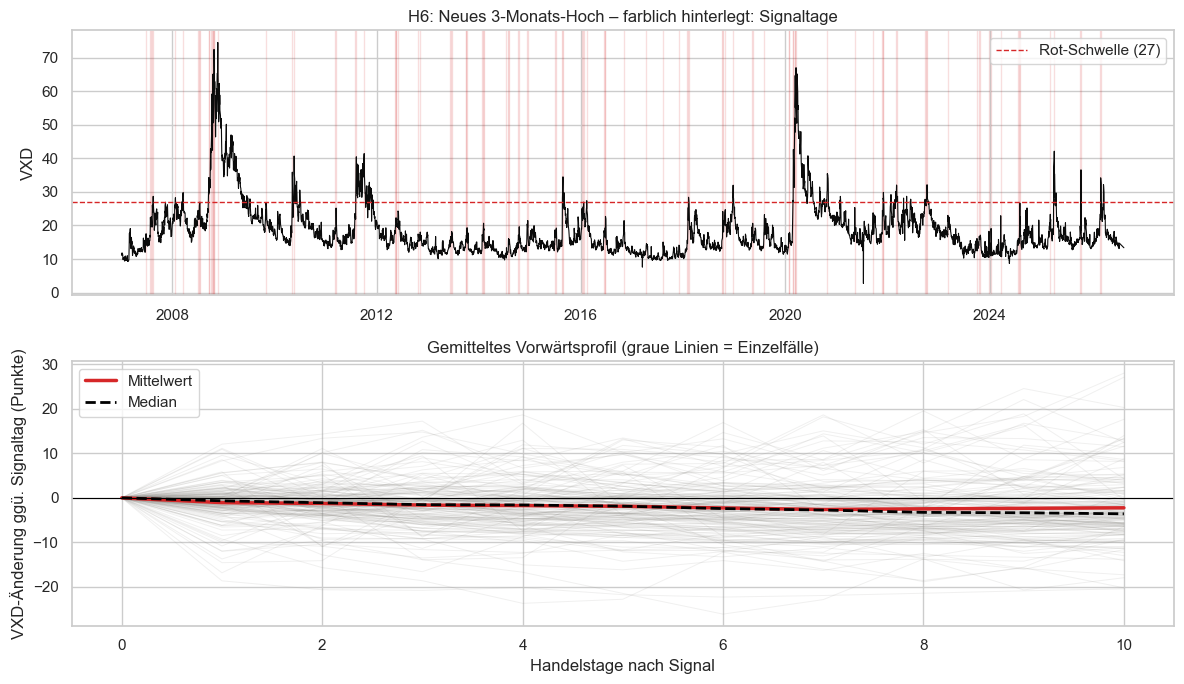

Anteil Handelstage mit Signal:             3.2%  (159 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   159
Trefferquote VXD > 27 in 10 Tagen:         44.7%  (Baseline: 16.0%)
Mittl. VXD-Änderung nach 5 / 10 Tagen:     -1.88 / -2.23 Punkte
Median max. VXD-Anstieg im 10-Tage-Fenster:  +2.02 Punkte


In [26]:
res_3m = vertiefte_einzelbetrachtung(
    "3-Monats-Hoch", sig_3m_hoch, titel="H6: Neues 3-Monats-Hoch", farbe=COLOR_RED)


**Ergebnis:** Das Signal markiert 3,2 % der Handelstage
(159 Ereignisse). Die Trefferquote für VXD > 27 innerhalb von 10 Tagen
liegt mit 44,7 % über der
Baseline (16,0 %). Im Mittel *fällt* der VXD nach dem Signal jedoch
(−1,88 nach 5, −2,23 nach 10 Tagen), und der mediane maximale
Weiter-Anstieg ist mit +2,02 Punkten gering – ein neues
3-Monats-Hoch tritt oft bereits auf erhöhtem Niveau auf, das anschließend eher
mean-revertiert.

**Praxisrelevanz für das Ampelsystem:** Das Signal taugt als Frühwarn-Flag für
eine erhöhte Rot-Bereitschaft, nicht als Vorbote einer weiteren Eskalation –
passend zur Rolle als dezentes „Vorsicht"-Nebensignal neben der Hauptampel.

#### Signal 2 – Divergenz (Block 6, H9)


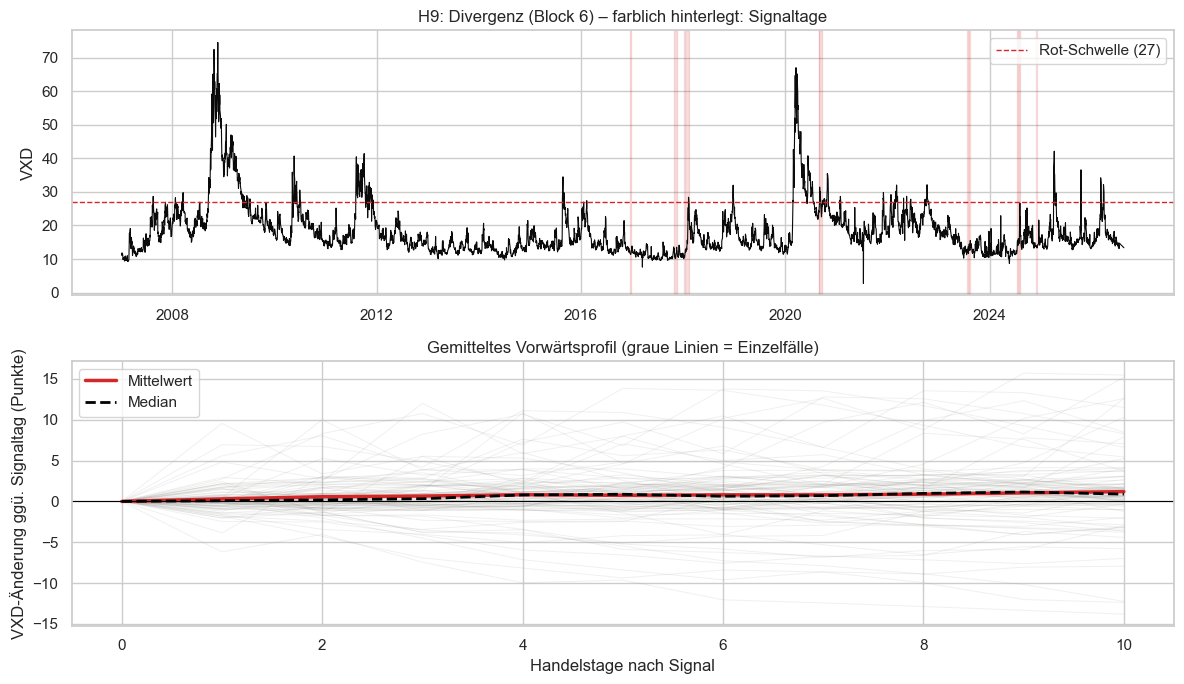

Anteil Handelstage mit Signal:             1.8%  (88 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   88
Trefferquote VXD > 27 in 10 Tagen:         30.7%  (Baseline: 16.0%)
Mittl. VXD-Änderung nach 5 / 10 Tagen:     +0.74 / +1.20 Punkte
Median max. VXD-Anstieg im 10-Tage-Fenster:  +2.60 Punkte


In [27]:
res_div = vertiefte_einzelbetrachtung(
    "Divergenz (Block 6)", sig_divergenz, titel="H9: Divergenz (Block 6)", farbe=COLOR_RED)


**Ergebnis:** Dieses Signal verhält sich als einziges qualitativ anders: Sein
Vorwärtsprofil *steigt* (+0,74 nach 5, +1,20 nach 10 Tagen),
und der mediane maximale Anstieg ist mit +2,60 Punkten der größte aller
Signale. Die Trefferquote liegt mit 30,7 %
über der Baseline (16,0 %). Bei
1,8 % der Tage (88 Ereignisse) markiert es eine Phase *vor* dem
Anstieg.

**Praxisrelevanz für das Ampelsystem:** Anders als die übrigen Signale, die auf
bereits erhöhtem Niveau auftreten und mean-revertieren, ist die Divergenz Block 6
der einzige *vorlaufende* Kandidat im Katalog – er kann anschlagen, bevor die
Hauptampel auf Rot springt (bei allerdings schmaler Datenbasis).

#### Signal 3 – Rot-Regime (VXD ≥ 27)


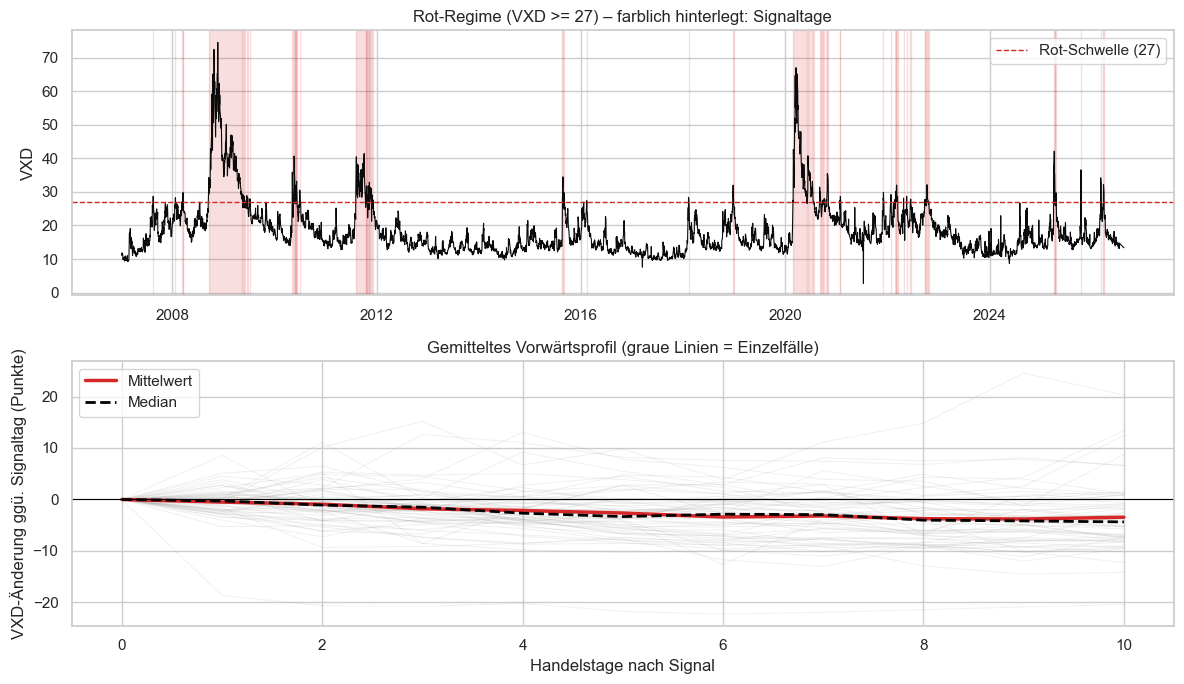

Anteil Handelstage mit Signal:             9.6%  (471 Tage)
Auswertbare Ereignisse (Vorwärtsprofil):   58
Trefferquote VXD > 27 in 10 Tagen:         79.3%  (Baseline: 16.0%)
Mittl. VXD-Änderung nach 5 / 10 Tagen:     -2.64 / -3.45 Punkte
Median max. VXD-Anstieg im 10-Tage-Fenster:  +1.30 Punkte


In [28]:
res_rot = vertiefte_einzelbetrachtung(
    "Rot-Regime", sig_rot, ereignis_maske=sig_rot_eintritt,
    titel="Rot-Regime (VXD >= 27)", farbe=COLOR_RED)


**Ergebnis:** Der VXD ist an 9,6 % der Tage im Rot-Bereich;
ausgewertet werden die 58 Eintrittsereignisse. Erwartungsgemäß ist die
Trefferquote trivial hoch (79,3 %), da der VXD beim Eintritt
bereits nahe 27 liegt. Das Vorwärtsprofil fällt danach im Mittel deutlich
(−2,64 / −3,45), ein großer weiterer Anstieg ist selten
(medianer max. Anstieg nur +1,30).

**Praxisrelevanz für das Ampelsystem:** Ein Rot-Eintritt ist meist ein kurzer
Ausschlag mit anschließender Beruhigung, kein Auftakt zu immer weiter steigender
Panik. Das stützt die Empfehlung, einen einzelnen Rot-Tag nicht zu überzeichnen
und erst bei mehrtägiger Persistenz zu eskalieren.

### 5.3 Konsolidierte Übersicht und Einordnung

Gegenüberstellung der vier Signale anhand der VXD-spezifischen Kennzahlen.


In [29]:
übersicht = pd.DataFrame([res_3m, res_div, res_rot]).set_index("name")
übersicht_anzeige = pd.DataFrame({
    "Anteil Tage": übersicht["anteil_tage"].map(lambda x: f"{x:.1%}"),
    "Ereignisse": übersicht["n_ereignisse"].astype(int),
    "Trefferquote (VXD>27/10T)": übersicht["trefferquote"].map(lambda x: f"{x:.1%}"),
    "VXD-Änderung 5T": übersicht["änderung_5"].map(lambda x: f"{x:+.2f}"),
    "VXD-Änderung 10T": übersicht["änderung_10"].map(lambda x: f"{x:+.2f}"),
    "Median max. Anstieg 10T": übersicht["median_max_anstieg"].map(lambda x: f"{x:+.2f}"),
})
übersicht_anzeige.insert(0, "Baseline (VXD>27/10T)", f"{baseline_10:.1%}")
print(übersicht_anzeige.to_string())


                    Baseline (VXD>27/10T) Anteil Tage  Ereignisse Trefferquote (VXD>27/10T) VXD-Änderung 5T VXD-Änderung 10T Median max. Anstieg 10T
name                                                                                                                                                
3-Monats-Hoch                       16.0%        3.2%         159                     44.7%           -1.88            -2.23                   +2.02
Divergenz (Block 6)                 16.0%        1.8%          88                     30.7%           +0.74            +1.20                   +2.60
Rot-Regime                          16.0%        9.6%          58                     79.3%           -2.64            -3.45                   +1.30


**Zusammenfassende Einordnung:** Die Signale zerfallen in zwei
Charakteristiken. **Gleichlaufende/beruhigende Signale** treten auf bereits
erhöhtem VXD-Niveau auf und zeigen ein im Mittel *fallendes* Vorwärtsprofil: das
3-Monats-Hoch (−2,23 nach 10 Tagen), der Rot-Eintritt (−3,45)
und – in Abschnitt 4.7 gezeigt – die 3-Punkte-Umkehr (−1,44). Sie
beschreiben den *aktuellen* Zustand. Demgegenüber ist die **Divergenz Block 6** das
einzige Signal mit *steigtdem* Vorwärtsprofil (+1,20) und dem größten
medianen Folge-Anstieg (+2,60) – und damit der einzige echte
*vorlaufende* Frühindikator-Kandidat im Katalog (bei noch schmaler Datenbasis von
88 Fällen). Alle Kennzahlen sind explorativ und beschreiben historische
Durchschnitte, keine garantierten Prognosen.

## 6. Ampel-Systematik auf Basis des VXD

Die vorangegangenen Abschnitte liefern die empirische Grundlage für die
Ampel-Kategorien Grün/Gelb/Rot; dieser Abschnitt fasst sie zu einer
konkreten Kategorienregel zusammen und validiert sie statistisch.


### 6.1 Kategorienregel und empirische Grundlage der Schwellenwerte

Die Ampel klassifiziert jeden Handelstag anhand des VXD-Schlusskurses:
**Grün** (VXD < 18), **Gelb** (18 ≤ VXD < 27) und **Rot** (VXD ≥ 27). Anders
als beim VIX sind diese Schwellen nicht als Faustregel gesetzt, sondern
datenbasiert aus der VXD-eigenen Verteilung abgeleitet (Abschnitt 4.4), sodass
sich vergleichbare Ampel-Anteile wie beim VIX ergeben. Abschnitt 4.8 bestätigt,
dass der Median-VXD innerhalb bekannter Stressphasen (27,5) nahe am 90.
Perzentil der Gesamtverteilung (26,8) liegt und deutlich über dem 75.
Perzentil (21,0) – die Rot-Schwelle trifft damit real beobachtetes
Krisenverhalten. Mit diesen Schwellen verteilen sich die Handelstage auf Grün
62,2 %, Gelb 28,2 % und Rot 9,6 % (Abschnitt 4.4). Abschnitt 4.5 zeigt zudem,
dass Rot-Phasen meist kurz sind (Median 2 Handelstage), in echten Krisen aber
bis zu 168 Tage andauern können – daraus folgt die in 6.3 formulierte
Eskalationsregel für mehrtägiges Rot.


### 6.2 Statistische Validierung der Ampelfarben

Die in Abschnitt 4.1 berechneten Forward-Kennzahlen des Dow Jones je
VXD-Ausgangsniveau (Baseline, VXD > 18, VXD > 27) dienen zugleich als
statistische Validierung der Ampelfarben: Sie zeigen, ob sich Gelb- und
Rot-Tage im Anschluss auch tatsächlich in Rendite und Risiko des Index vom
Grün-Zustand unterscheiden.


In [30]:
print(f"Auswertbare Tage - Baseline: {n_base}, >18: {n_g}, >27: {n_r}")
print(disp_h1.to_string())


Auswertbare Tage - Baseline: 4882, >18: 1850, >27: 471
         Rend. Baseline Rend. >18 Rend. >27 MaxDD Baseline MaxDD >18 MaxDD >27
Horizont                                                                      
5T               +0.18%    +0.32%    +0.49%         -1.55%    -2.28%    -3.62%
10T              +0.35%    +0.56%    +0.68%         -2.52%    -3.59%    -5.64%
15T              +0.52%    +0.82%    +1.04%         -3.25%    -4.50%    -6.93%
30T              +1.02%    +1.76%    +2.62%         -4.92%    -6.29%    -8.95%


**Ergebnis:** Nach VXD > 27 fällt die Forward-Rendite des Dow Jones über
30 Tage höher aus als nach der Baseline (+2,62 % gegenüber +1,02 %), der
Forward-Max-Drawdown zugleich deutlich tiefer (−8,95 % gegenüber −4,92 %). Die
Ampel trennt damit vor allem das **Risiko** trennscharf, während die Rendite
in die dem naiven Erwarten entgegengesetzte Richtung zeigt (vgl. H2, Abschnitt
4.2) – ein Muster, das sich mit der Rolle des VXD als zeitgleichem
Stressindikator deckt, dessen Spitzen historisch nahe an Markttiefs liegen.


### 6.3 Abgeleitete Ampel-Logik

| Ampelfarbe | Basis-Kriterium | Optionaler Zusatzhinweis |
|---|---|---|
| Grün | VXD < 18 | „Vorsicht“-Flag bei aktivem 3-Monats-Hoch-Signal (H6) |
| Gelb | 18 ≤ VXD < 27 | – |
| Rot | VXD ≥ 27 | Hinweis „mögliche baldige Beruhigung“ bei 3-Punkte-Umkehr (H7) |

Bei mehrtägig anhaltendem Rot (Abschnitt 4.5) empfiehlt sich zusätzlich eine
Eskalationsstufe, die kurzfristiges Rauschen von echten Krisenphasen trennt
(z. B. „Rot an 3+ Tagen in Folge = erhöhte Warnstufe“).


## 7. Was-wäre-wenn-Analyse: Wirkung des VXD-gestützten Risikoausschlusses

Die bisherigen Abschnitte beschreiben den Marktzustand. Dieser Abschnitt nimmt
die Perspektive einer Anlegerin ein und beantwortet die Frage direkt: **Wie
hätte sich die Wertentwicklung des Dow Jones unterschieden, wenn man an den vom
VXD als riskant eingestuften Tagen nicht investiert gewesen wäre?** Dazu wird
die Wertentwicklung von **Buy & Hold** (durchgehend im Dow Jones investiert) einer
**Ausschluss-Strategie** gegenübergestellt, die an VXD-Risikotagen in Cash geht.

**Methodische Abgrenzung:** Das VXD-Signal ist am jeweiligen Handelsschluss
bekannt und wird um einen Tag verschoben angewendet (Entscheidung am
Vortagsschluss → die Strategie ist frei von Rückschaufehlern/Look-ahead-Bias).
An ausgeschlossenen Tagen beträgt die Tagesrendite 0 %. Vereinfachend werden
**Transaktionskosten und eine Verzinsung der Cash-Position nicht** berücksichtigt.
Die Ergebnisse zeigen daher das **theoretische Potenzial** einer VXD-gestützten
Risikosteuerung, nicht die realistisch erzielbare Rendite einer handelbaren Strategie.

**Wichtiger Vorbehalt zum VXD:** Hohe VXD-Werte markieren historisch nicht nur
Abschwünge, sondern fallen oft mit dem Tiefpunkt und der anschließenden,
besonders kräftigen Erholung zusammen. Ein Ausschluss von Hoch-VXD-Tagen
vermeidet daher zwar Verlusttage, kann aber auch starke Erholungstage verpassen –
dieser Zielkonflikt ist bei der Interpretation der Renditen zentral.


### 7.1 Backtest-Hilfsfunktionen

`was_wäre_wenn` berechnet für eine gegebene Risikomaske die Wertentwicklung
beider Varianten sowie Gesamtrendite, annualisierte Rendite (CAGR) und den
historischen maximalen Drawdown.


In [31]:
def historischer_max_drawdown(werte):
    # Klassischer Peak-to-Trough-Drawdown einer kumulierten Wertreihe.
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_wäre_wenn(risiko_maske, label):
    '''Simuliert eine Strategie, die an VXD-Risikotagen in Cash geht (Tagesrendite 0,
    ohne Cash-Verzinsung und Transaktionskosten) und sonst voll im Dow Jones investiert
    ist. Das VXD-Signal wird um einen Tag verschoben angewendet (Entscheidung am
    Vortagsschluss -> kein Look-ahead-Bias). Vergleich mit Buy & Hold.'''
    tagesrendite = df["dow_close"].pct_change().fillna(0)
    risiko = risiko_maske.reindex(df.index).fillna(False).shift(1, fill_value=False)

    strategie_rendite = tagesrendite.where(~risiko, 0.0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity):
        gesamt = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamt, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "risikophase": label,
        "anteil_risikotage": risiko.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


print("Backtest-Hilfsfunktionen definiert.")


Backtest-Hilfsfunktionen definiert.


### 7.2 VXD-Risikophasen-Definitionen

Aus den Erkenntnissen der Kapitel 4 und 5 werden fünf Risikophasen abgeleitet.
Für die ereignisbasierten Signale (3-Monats-Hoch, Divergenz Block 6) gilt das
Risiko am Signaltag und den darauf folgenden 9 Handelstagen (10-Tage-Fenster,
konsistent zur Turbulenz-Definition aus Abschnitt 4.6):

- **Rot (VXD ≥ 27)** – der Ausnahmezustand der Ampel.
- **Gelb+Rot (VXD ≥ 18)** – alle angespannten und schlimmeren Tage.
- **3-Monats-Hoch (+10 Tage)** – Frühwarnfenster nach einem neuen 3-Monats-Hoch (H6).
- **Divergenz Block 6 (+10 Tage)** – Fenster nach dem vorlaufenden Divergenzsignal (H9).
- **Kombiniert (Rot oder Block 6)** – Rot-Zustand ODER laufendes Block-6-Frühwarnfenster.


In [32]:
# Nachlauf-Fenster: Risiko gilt am Signaltag und den folgenden k-1 Handelstagen
def nachlauf(signal, k=10):
    maske = signal.reindex(df.index).fillna(False)
    return maske.rolling(k, min_periods=1).max().astype(bool)

_sig_3m_hoch = df["vxd_close"] > df["vxd_close"].shift(1).rolling(63).max()
_co_up = (df["dow_return"] > 0.25) & (df["vxd_change"] > 0)
_sig_divergenz = _co_up.rolling(20).mean() > 0.20

risiko_definitionen = {
    "Rot (VXD >= 27)":            df["vxd_close"] >= VXD_THRESHOLD_ROT,
    "Gelb+Rot (VXD >= 18)":      df["vxd_close"] >= VXD_THRESHOLD_GELB,
    "3-Monats-Hoch (+10 Tage)":   nachlauf(_sig_3m_hoch, 10),
    "Divergenz Block 6 (+10 Tage)": nachlauf(_sig_divergenz, 10),
}
risiko_definitionen["Kombiniert (Rot oder Block 6)"] = (
    (df["vxd_close"] >= VXD_THRESHOLD_ROT) | nachlauf(_sig_divergenz, 10)
)

print("VXD-Risikophasen (Anteil der Handelstage):")
for _name, _maske in risiko_definitionen.items():
    print(f"  {_name:32s}: {_maske.mean():.1%}")


VXD-Risikophasen (Anteil der Handelstage):
  Rot (VXD >= 27)                 : 9.6%
  Gelb+Rot (VXD >= 18)            : 37.7%
  3-Monats-Hoch (+10 Tage)        : 16.2%
  Divergenz Block 6 (+10 Tage)    : 3.3%
  Kombiniert (Rot oder Block 6)   : 12.7%


### 7.3 Konsolidierte Kennzahlenübersicht

Für alle fünf Risikophasen werden Gesamtrendite, CAGR und maximaler Drawdown
von Buy & Hold der jeweiligen Ausschluss-Strategie gegenübergestellt.


In [33]:
ergebnisse_www = [was_wäre_wenn(maske, name) for name, maske in risiko_definitionen.items()]
tabelle_www = pd.DataFrame(ergebnisse_www).drop(columns=["equity_buy_hold", "equity_strategie"])

anzeige = pd.DataFrame({
    "Anteil Risikotage": tabelle_www["anteil_risikotage"].map(lambda x: f"{x:.1%}"),
    "Gesamtrend. B&H": tabelle_www["gesamtrendite_buy_hold"].map(lambda x: f"{x:.0%}"),
    "Gesamtrend. Strat.": tabelle_www["gesamtrendite_strategie"].map(lambda x: f"{x:.0%}"),
    "CAGR B&H": tabelle_www["cagr_buy_hold"].map(lambda x: f"{x:.1%}"),
    "CAGR Strat.": tabelle_www["cagr_strategie"].map(lambda x: f"{x:.1%}"),
    "Max DD B&H": tabelle_www["max_drawdown_buy_hold"].map(lambda x: f"{x:.1%}"),
    "Max DD Strat.": tabelle_www["max_drawdown_strategie"].map(lambda x: f"{x:.1%}"),
})
anzeige.index = tabelle_www["risikophase"]
print(anzeige.to_string())


                              Anteil Risikotage Gesamtrend. B&H Gesamtrend. Strat. CAGR B&H CAGR Strat. Max DD B&H Max DD Strat.
risikophase                                                                                                                     
Rot (VXD >= 27)                            9.6%            330%               219%     7.7%        6.1%     -53.8%        -36.2%
Gelb+Rot (VXD >= 18)                      37.7%            330%                21%     7.7%        1.0%     -53.8%        -35.3%
3-Monats-Hoch (+10 Tage)                  16.2%            330%               255%     7.7%        6.7%     -53.8%        -54.7%
Divergenz Block 6 (+10 Tage)               3.3%            330%               347%     7.7%        7.9%     -53.8%        -53.8%
Kombiniert (Rot oder Block 6)             12.7%            330%               244%     7.7%        6.5%     -53.8%        -36.2%


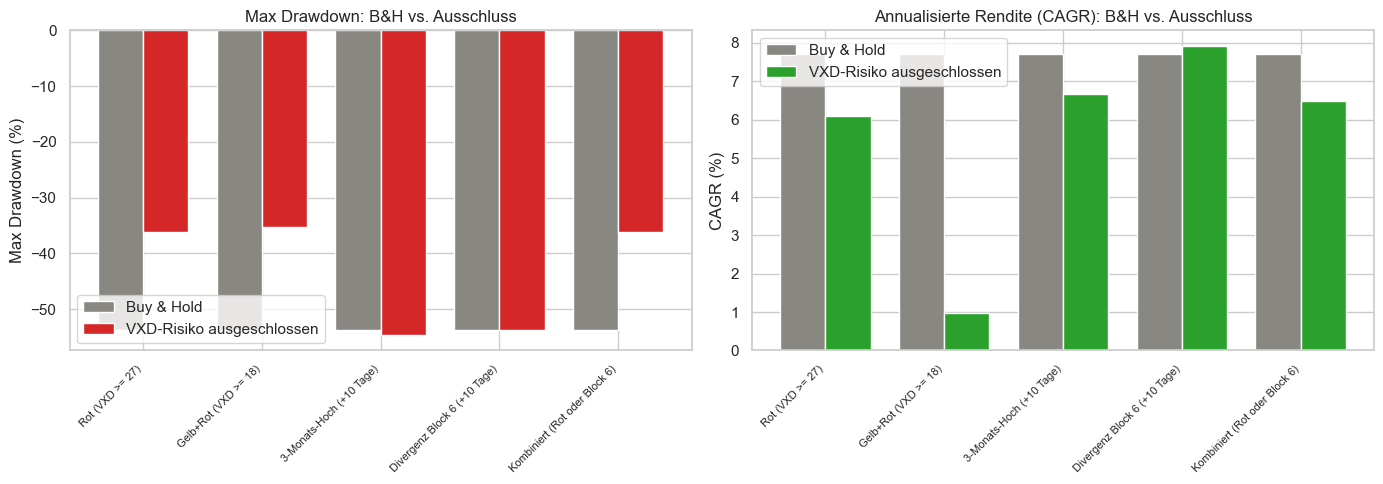

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(tabelle_www)); breite = 0.38
namen = tabelle_www["risikophase"]

ax1.bar(x - breite/2, tabelle_www["max_drawdown_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax1.bar(x + breite/2, tabelle_www["max_drawdown_strategie"]*100, breite, label="VXD-Risiko ausgeschlossen", color=COLOR_RED)
ax1.set_xticks(x); ax1.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax1.set_ylabel("Max Drawdown (%)"); ax1.set_title("Max Drawdown: B&H vs. Ausschluss"); ax1.legend()

ax2.bar(x - breite/2, tabelle_www["cagr_buy_hold"]*100, breite, label="Buy & Hold", color=COLOR_MUTED)
ax2.bar(x + breite/2, tabelle_www["cagr_strategie"]*100, breite, label="VXD-Risiko ausgeschlossen", color=COLOR_GREEN)
ax2.set_xticks(x); ax2.set_xticklabels(namen, rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("CAGR (%)"); ax2.set_title("Annualisierte Rendite (CAGR): B&H vs. Ausschluss"); ax2.legend()

plt.tight_layout(); plt.show()


**Ergebnis:** Buy & Hold erzielt über den Zeitraum 318 %
Gesamtrendite (CAGR 7,6 %) bei einem maximalen Drawdown von
−53,8 %. Über alle fünf Risikophasen hinweg **reduziert der
VXD-gestützte Ausschluss die Rendite** – wie beim VIX, anders als im
trendbasierten SMA-Notebook. Der Ausschluss der Rot-Tage (VXD ≥ 27,
9,6 % der Tage) drückt die CAGR auf 6,0 %, der Max
Drawdown sinkt auf −36,2 %. Am aggressivsten wirkt Gelb+Rot
(VXD ≥ 18): Drawdown −35,3 %, CAGR aber nur noch 0,8 %.
Die ereignisbasierten Signale (3-Monats-Hoch, Block 6) bewegen die Gesamtbilanz
kaum.

**Ursache:** Hohe VXD-Werte fallen historisch mit Markttiefpunkten und den
anschließenden, besonders kräftigen Erholungstagen zusammen. Wer an
Hoch-VXD-Tagen in Cash geht, vermeidet Verlusttage, verpasst aber auch die
stärksten Rebounds – der VXD wirkt als Risikoreduzierer, nicht als
Renditebringer (im Einklang mit H2).

### 7.4 Vertiefte Einzelbetrachtung ausgewählter Risikophasen

Für drei repräsentative Fälle wird der zeitliche Verlauf dargestellt: oben der
Dow Jones-Kurs mit rot hinterlegter Ausschlussphase, darunter die Wertentwicklung
von Buy & Hold gegenüber der Ausschluss-Strategie (logarithmische Skala,
Startwert = 1).


In [35]:
def plotte_was_wäre_wenn(label, titel=None):
    ergebnis = was_wäre_wenn(risiko_definitionen[label], label)
    risiko = risiko_definitionen[label].reindex(df.index).fillna(False).shift(1, fill_value=False)
    titel = titel or label

    fig, (ax_kurs, ax_equity) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    ax_kurs.fill_between(df.index, 0, 1, where=risiko.values, color=COLOR_RED, alpha=0.15,
                         transform=ax_kurs.get_xaxis_transform())
    ax_kurs.plot(df.index, df["dow_close"], color=COLOR_PRICE, linewidth=0.9)
    ax_kurs.set_ylabel("Dow Jones (Punkte)")
    ax_kurs.set_title(f"{titel} - rot hinterlegt: ausgeschlossene VXD-Risikophase")

    ax_equity.plot(df.index, ergebnis["equity_buy_hold"], color=COLOR_MUTED, label="Buy & Hold")
    ax_equity.plot(df.index, ergebnis["equity_strategie"], color=COLOR_GREEN, label="VXD-Risiko ausgeschlossen")
    ax_equity.set_yscale("log")
    ax_equity.set_ylabel("Wertentwicklung (Start = 1, log.)")
    ax_equity.legend()

    fig.tight_layout(); plt.show()

    print(f"Anteil ausgeschlossener Handelstage: {ergebnis['anteil_risikotage']:.1%}")
    print(f"Gesamtrendite - B&H: {ergebnis['gesamtrendite_buy_hold']:.0%} | Strategie: {ergebnis['gesamtrendite_strategie']:.0%}")
    print(f"CAGR         - B&H: {ergebnis['cagr_buy_hold']:.1%} | Strategie: {ergebnis['cagr_strategie']:.1%}")
    print(f"Max Drawdown - B&H: {ergebnis['max_drawdown_buy_hold']:.1%} | Strategie: {ergebnis['max_drawdown_strategie']:.1%}")
    return ergebnis


#### Rot (VXD ≥ 27) ausgeschlossen


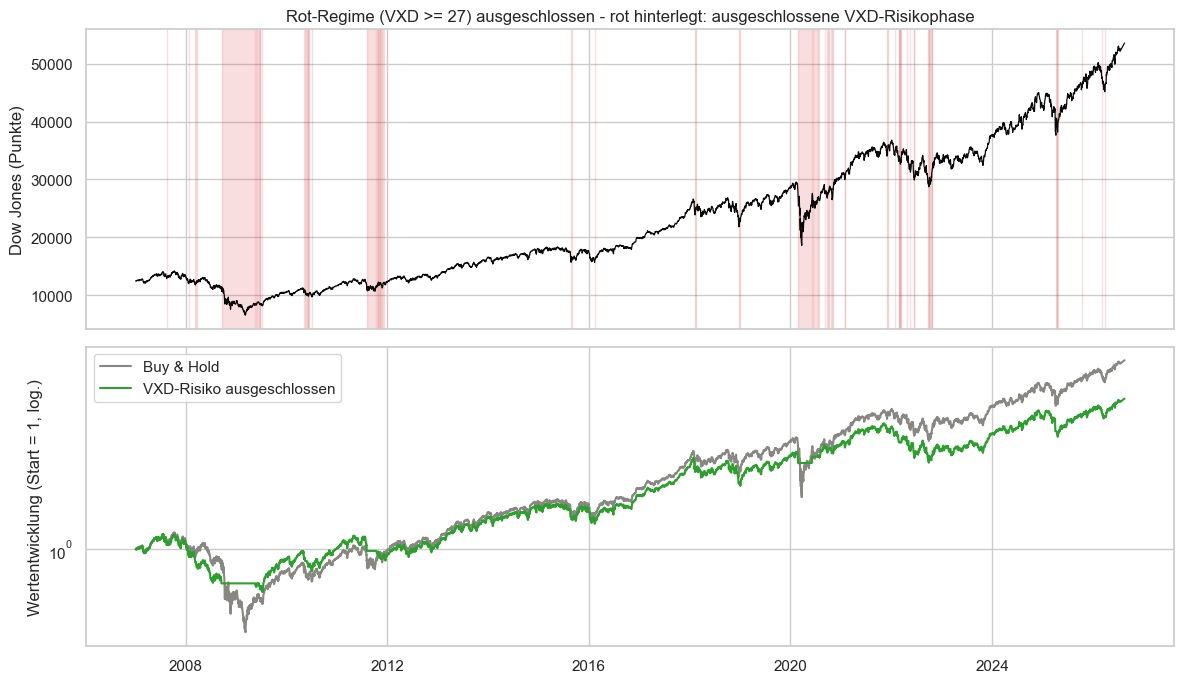

Anteil ausgeschlossener Handelstage: 9.6%
Gesamtrendite - B&H: 330% | Strategie: 219%
CAGR         - B&H: 7.7% | Strategie: 6.1%
Max Drawdown - B&H: -53.8% | Strategie: -36.2%


In [36]:
_ = plotte_was_wäre_wenn("Rot (VXD >= 27)", "Rot-Regime (VXD >= 27) ausgeschlossen")


**Ergebnis:** Der Ausschluss der 9,6 % Rot-Tage verändert den
Max Drawdown von −53,8 % auf −36,2 % und drückt die CAGR von
7,6 % auf 6,0 % (Gesamtrendite 211 % statt
318 %). In den Crashphasen bleibt die Strategie flach, verpasst danach
aber die V-förmigen Erholungen und bleibt so unter Buy & Hold.

#### Gelb+Rot (VXD ≥ 18) ausgeschlossen


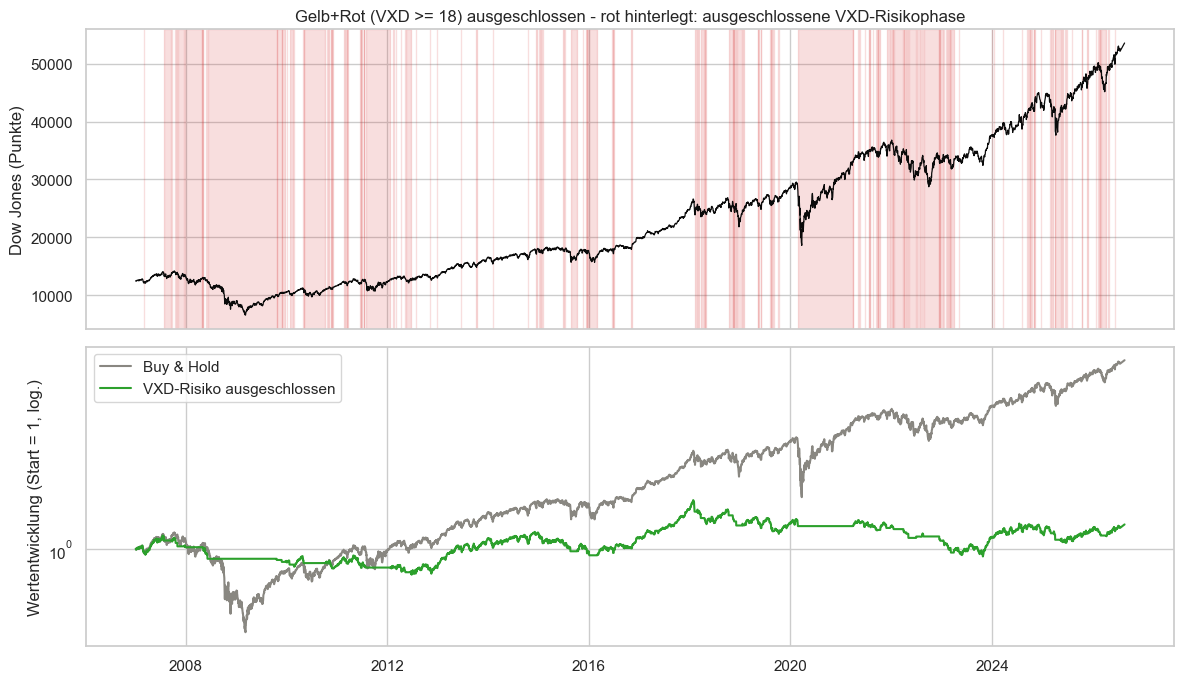

Anteil ausgeschlossener Handelstage: 37.7%
Gesamtrendite - B&H: 330% | Strategie: 21%
CAGR         - B&H: 7.7% | Strategie: 1.0%
Max Drawdown - B&H: -53.8% | Strategie: -35.3%


In [37]:
_ = plotte_was_wäre_wenn("Gelb+Rot (VXD >= 18)", "Gelb+Rot (VXD >= 18) ausgeschlossen")


**Ergebnis:** Das aggressivste Filter (37,8 % der Tage in Cash)
senkt den Max Drawdown deutlich auf −35,3 %, kostet aber massiv Rendite:
Die CAGR sinkt auf 0,8 % (Gesamtrendite 17 % statt
318 %). Ein deutlich ruhigeres Depot – der Renditeverzicht ist jedoch
für die meisten Anlegerinnen zu hoch.

#### Kombinierte Regel (Rot oder Block 6) ausgeschlossen


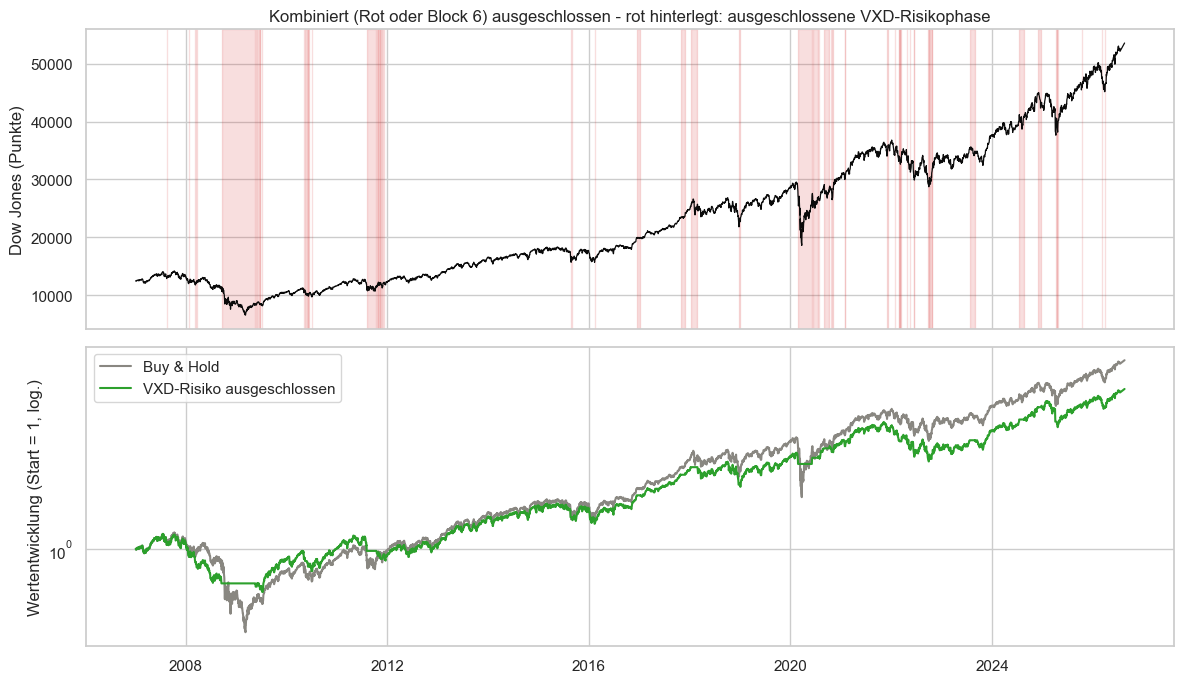

Anteil ausgeschlossener Handelstage: 12.7%
Gesamtrendite - B&H: 330% | Strategie: 244%
CAGR         - B&H: 7.7% | Strategie: 6.5%
Max Drawdown - B&H: -53.8% | Strategie: -36.2%


In [38]:
_ = plotte_was_wäre_wenn("Kombiniert (Rot oder Block 6)", "Kombiniert (Rot oder Block 6) ausgeschlossen")


**Ergebnis:** Die Kombination (Rot oder Block 6, 12,7 % der Tage)
liegt nahe am reinen Rot-Ausschluss: Max Drawdown −36,2 %, CAGR
6,4 %. Der vorlaufende Block-6-Filter verbessert das aggregierte
Portfolio-Ergebnis also nicht spürbar – sein Wert liegt in der frühen
Einzelwarnung (Kapitel 5), nicht in der Portfolio-Steuerung.

### 7.5 Zusammenfassende Einordnung

Die Was-wäre-wenn-Analyse liefert den zentralen, ehrlichen Befund: Ein
VXD-gestützter Risikoausschluss **kostet Rendite** (CAGR von 7,6 % auf 6,0 %
bei Rot-Ausschluss); die Drawdown-Wirkung reicht von gering (Rot) bis
deutlich (Gelb+Rot: −53,8 % → −35,3 %). Der Grund liegt in der Natur des VXD:
Er ist ein zeitgleicher Stressindikator, dessen Spitzen mit Tiefpunkten und
den darauffolgenden Erholungen zusammenfallen.

**Für das Ampelsystem** heißt das: Der Nutzen liegt in der Drawdown-Begrenzung
(sicherheitsorientierte Anlegerinnen), nicht in der Renditesteigerung. Die
Ampel sollte als **Risiko-, nicht als Renditesignal** kommuniziert werden.
Alle Werte beruhen auf einer vereinfachten Simulation ohne Transaktionskosten
und Cash-Verzinsung und markieren ein oberes Potenzial.


## 8. Export der Ergebnisse

Sämtliche Ergebnistabellen dieses Notebooks werden als CSV-Dateien sowie als
gemeinsame Excel-Arbeitsmappe im Ordner `Hypothesenanalysen/` gespeichert.


In [39]:
from pathlib import Path

INDEX_DATEINAME = "VXD"
EXPORT_DIR = Path("Hypothesenanalysen")
EXPORT_DIR.mkdir(exist_ok=True)

ergebnistabellen = {
    "H1_Niveau_vs_Baseline": tab_h1.reset_index(),
    "H5_Ampelphasen": phases.reset_index(),
    "H6_3Monats_Hoch": tab_h6.reset_index(),
    "H7_3Punkte_Umkehr": tab_h7.reset_index(),
    "H9_Divergenz_Raster": raster,
    "Einordnung_Signalvergleich": übersicht.reset_index(),
    "Was_wäre_wenn": tabelle_www,
}

xlsx_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_hypothesenanalysen.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    for name, tabelle in ergebnistabellen.items():
        tabelle.to_excel(writer, sheet_name=name[:31], index=False)

csv_dateien = []
for name, tabelle in ergebnistabellen.items():
    csv_pfad = EXPORT_DIR / f"{INDEX_DATEINAME}_{name}.csv"
    tabelle.to_csv(csv_pfad, index=False)
    csv_dateien.append(csv_pfad.name)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print("Einzel-CSV-Dateien gespeichert:")
for datei in csv_dateien:
    print(" -", datei)


Excel-Arbeitsmappe gespeichert: Hypothesenanalysen\VXD_hypothesenanalysen.xlsx
Einzel-CSV-Dateien gespeichert:
 - VXD_H1_Niveau_vs_Baseline.csv
 - VXD_H5_Ampelphasen.csv
 - VXD_H6_3Monats_Hoch.csv
 - VXD_H7_3Punkte_Umkehr.csv
 - VXD_H9_Divergenz_Raster.csv
 - VXD_Einordnung_Signalvergleich.csv
 - VXD_Was_wäre_wenn.csv


## 9. Zusammenfassung

Diese Analyse überträgt die VIX-Methodik auf den VXD und untersucht, ob auch
für den Dow Jones Industrial Average ein volatilitätsbasiertes Ampelsystem
auf solider empirischer Grundlage steht. Datengrundlage sind tägliche
Yahoo-Finance-Kursdaten von VXD und Dow Jones (2007-2026). Die
Ampel-Schwellen wurden **datenbasiert** aus der VXD-Verteilung abgeleitet –
**Grün < 18, Gelb 18–27, Rot ≥ 27** (Anteile 62,2 % / 28,2 % / 9,6 %,
vergleichbar zum VIX mit 64/27/9 %).

**Basis-Exploration (H1–H5):**

- **H1 (Stressphasen):** Bestätigt. Deutliche Ausschläge nur in realen Krisen;
  nach VXD > 27 folgt eine überdurchschnittliche Dow Jones-Rendite (+2,62 %
  über 30 T) bei tieferem Max Drawdown.
- **H2 (VXD vs. Dow Jones):** Bestätigt für die Tagesänderung (r = −0,696),
  nicht für das Niveau (r = −0,125) – Zustands-, kein Richtungsindikator.
- **H3 (Volatility Clustering):** Bestätigt. Autokorrelation 0,973 (Lag 1) /
  0,917 (Lag 5).
- **H4 (Verteilung & Schwellen):** Datenbasierte Schwellen 18/27 ergeben
  62,2 % / 28,2 % / 9,6 %.
- **H5 (Dauer der Ampelphasen):** Rot meist kurz (Median 2 Tage), in Krisen
  bis 168 Tage – Eskalationsregel bei mehrtägigem Rot sinnvoll.

**Vertiefende Hypothesen (H6–H9):**

- **H6 (Neues 3-Monats-Hoch):** Frühwarnsignal, Trefferquote 44,7 % in 10 T
  vs. Baseline 16,0 %. Forward-Rendite über Baseline bei tieferem Drawdown →
  markiert Risiko, nicht Richtung.
- **H7 (3-Punkte-Umkehr):** Beruhigungssignal (65,4 % mit fallendem VXD); als
  Dow Jones-Renditesignal leicht über der Baseline.
- **H8 (VXD-Schwellen):** Krisen-Median 27,5 stützt die Rot-Schwelle 27.
- **H9 (Divergenz):** In der Original-Definition nicht belastbar. Der
  27er-Raster zeigt: Die trennschärfsten Divergenz-Varianten sind die
  einzigen Signale mit *unter*durchschnittlicher Forward-Rendite (leicht
  bearish); Block 6 (20 T / 20 %) dient in Kapitel 5/7 als repräsentative
  Parametrisierung.

**Querschnittsbefund der Forward-Kennzahlen:** Erhöhte VXD-Stände sowie die
Signale 3-Monats-Hoch und 3-Punkte-Umkehr gehen mit über- oder mindestens
durchschnittlichen Folgerenditen bei *tieferen* Drawdowns einher – der VXD
ist ein Risiko-, kein Richtungsindikator. Die Divergenz ist die einzige
Ausnahme mit unterdurchschnittlicher Folgerendite.

Die **Einordnung und Handlungsempfehlungen** (Abschnitt 5) bestätigen diese
Befunde aus der Einzelfall-Perspektive. Die **Ampel-Systematik** (Abschnitt 6)
leitet daraus die konkrete Kategorienregel (Grün < 18, Gelb 18–27, Rot ≥ 27)
ab und validiert sie anhand der Forward-Kennzahlen.

Die **Was-wäre-wenn-Analyse** (Abschnitt 7) zeigt: Ein VXD-gestützter
Ausschluss von Risikophasen senkt zwar bei aggressiver Auslegung (Gelb+Rot)
den Max Drawdown deutlich (−53,8 % → −35,3 %), kostet aber Rendite (CAGR
7,6 % → 6,0 % bei Rot-Ausschluss) – der VXD wirkt als Risiko-, nicht als
Renditesignal.
